In [1]:
%load_ext autoreload
%autoreload 2

# I) Data

### 1) Feature set

We begin by extracting and cleaning our input financial data. This feature set consists of both technical and macro indicators.

In [2]:
import pandas as pd
import numpy as np
from data.scripts import data_generation
from data.scripts import analysis_utils

In [3]:
# Collect data across the past 26 years
start_date = "2000-01-01"
end_date = "2026-01-01"

# Call data generation functions to fetch data from APIs
technical_indicators = data_generation.get_yahoo_finance_data(start_date, end_date)
macro_indicators = data_generation.get_fred_input_data(start_date, end_date, api_key="0d472975ba8d0e5ee549648673b1e3de")
futures_indicators = data_generation.get_futures_data(start_date, end_date)
full_feature_set = pd.concat([technical_indicators, macro_indicators, futures_indicators], axis=1)
full_feature_set

YF.download() has changed argument auto_adjust default to True


,SPX_Close,SPX_Volume,SPX_ROC,SPX_RSI,SPX_MACD,SPX_MACDH,SPX_MACDS,VIX_Close,Real_GDP,Unemployment,Inflation,Fed_Funds_Rate,10Y2Y_Spread,Fed_Funds_Future,10Y_Treasury_Future
2000-01-01,1394.459961,21494400000,8.972832,64.370286,124.813665,-3.267604,128.081269,24.950001,13878.147,4.0,74.306,5.45,0.17,NaN,NaN
2000-02-01,1366.420044,20912000000,10.343777,61.625554,118.398196,-7.746459,126.144654,23.370001,13878.147,4.1,74.415,5.73,0.02,NaN,NaN
2000-03-01,1498.579956,26156200000,16.496806,68.453284,122.565235,-2.863535,125.428771,24.110001,13878.147,4.0,74.568,5.85,-0.13,NaN,NaN
2000-04-01,1452.430054,20106460000,8.781587,64.160327,120.751781,-3.741592,124.493373,26.200001,14130.908,3.8,74.617,6.02,-0.13,NaN,NaN
2000-05-01,1420.599976,19898300000,9.122474,61.304661,115.415744,-7.262103,122.677847,23.650000,14130.908,4.0,74.697,6.27,-0.44,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,6460.259766,99352030000,14.373272,71.301868,439.330585,26.192304,413.138281,15.360000,24026.834,4.3,126.714,4.33,0.54,95.669998,112.453125
2025-09-01,6688.459961,114074610000,16.069123,73.849586,467.369258,43.384782,423.984476,16.280001,24026.834,4.4,126.954,4.22,0.54,95.775002,112.500000
2025-10-01,6840.200195,129661660000,19.888877,75.412657,496.115369,57.704714,438.410655,17.440001,24065.956,4.4,127.245,4.09,0.57,95.912498,112.671875
2025-11-01,6849.089844,100880170000,13.538769,75.505030,513.692659,60.225604,453.467056,16.350000,24065.956,4.5,127.473,3.88,0.57,96.122498,113.421875


### 2) The Categorical Target Variable: Bull vs Bear Regime

Next, we add in our target variable, which describes which regime we're in (0 for bear, 1 for bull). Since we cannot directly observe which regime we're in, we estimate it by applying a formal 'Peak-to-Trough' algorithm,

### Why Peak-to-Trough algorithm

'Peak-to-Trough' algorithm in quantitative finance is the industry standard for Bull/Bear regime

Sources:
(https://corporatefinanceinstitute.com/resources/career-map/sell-side/capital-markets/bear-market/)
(https://www.spglobal.com/spdji/en/documents/additional-material/sp-500-brochure.pdf?utm_source=chatgpt.com)

- A **bear market** is defined as a **20% decline from a recent peak**  
- A **bull market** is defined as a **20% rise from a recent trough**

Supervised machine learning requires a **clear mathematical ground truth** for the target variable. Without a precise definition, the model cannot optimize its parameters or learn consistent patterns.

Using the 20% rule creates an **objective, deterministic label** for historical market regimes:

$$
Regime_{t} =
\begin{cases}
0 & \text{if } \frac{Price_{t} - Price_{peak}}{Price_{peak}} \le -0.20 \quad \text{(Bull)}\\
1 & \text{if } \frac{Price_{t} - Price_{trough}}{Price_{trough}} \ge 0.20  \quad \space \text{(Bear)}
\end{cases}
$$

We apply this with the S\&P 500 daily closing price.

Though funds own internal metrics to quantify regimes such as VIX threshold, the "20% rule" gives a concrete industry standard base truth for us to conduct analysis.

In [4]:
# Call regime classification function
regimes = analysis_utils.classify_regimes(full_feature_set)
full_data_set = full_feature_set.copy()
full_data_set["Regime"] = regimes
full_data_set

,SPX_Close,SPX_Volume,SPX_ROC,SPX_RSI,SPX_MACD,SPX_MACDH,SPX_MACDS,VIX_Close,Real_GDP,Unemployment,Inflation,Fed_Funds_Rate,10Y2Y_Spread,Fed_Funds_Future,10Y_Treasury_Future,Regime
2000-01-01,1394.459961,21494400000,8.972832,64.370286,124.813665,-3.267604,128.081269,24.950001,13878.147,4.0,74.306,5.45,0.17,NaN,NaN,1.0
2000-02-01,1366.420044,20912000000,10.343777,61.625554,118.398196,-7.746459,126.144654,23.370001,13878.147,4.1,74.415,5.73,0.02,NaN,NaN,1.0
2000-03-01,1498.579956,26156200000,16.496806,68.453284,122.565235,-2.863535,125.428771,24.110001,13878.147,4.0,74.568,5.85,-0.13,NaN,NaN,1.0
2000-04-01,1452.430054,20106460000,8.781587,64.160327,120.751781,-3.741592,124.493373,26.200001,14130.908,3.8,74.617,6.02,-0.13,NaN,NaN,1.0
2000-05-01,1420.599976,19898300000,9.122474,61.304661,115.415744,-7.262103,122.677847,23.650000,14130.908,4.0,74.697,6.27,-0.44,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,6460.259766,99352030000,14.373272,71.301868,439.330585,26.192304,413.138281,15.360000,24026.834,4.3,126.714,4.33,0.54,95.669998,112.453125,1.0
2025-09-01,6688.459961,114074610000,16.069123,73.849586,467.369258,43.384782,423.984476,16.280001,24026.834,4.4,126.954,4.22,0.54,95.775002,112.500000,1.0
2025-10-01,6840.200195,129661660000,19.888877,75.412657,496.115369,57.704714,438.410655,17.440001,24065.956,4.4,127.245,4.09,0.57,95.912498,112.671875,1.0
2025-11-01,6849.089844,100880170000,13.538769,75.505030,513.692659,60.225604,453.467056,16.350000,24065.956,4.5,127.473,3.88,0.57,96.122498,113.421875,1.0


# II) Data Cleaning

This section details the preparation of the dataset for modelling. The following steps provide the  statistical justification for every action/transformation taken to the dataset. To understand the data better (defintions) and see how it is all interconnected (explanation of the macroeconomics) please read analysis.md.

We start by providing some analysis on how macro indicators are correlated to future values of the SPX_Close at different lags (1, 6 and 12 Months). 

### 1) Feature Correlations

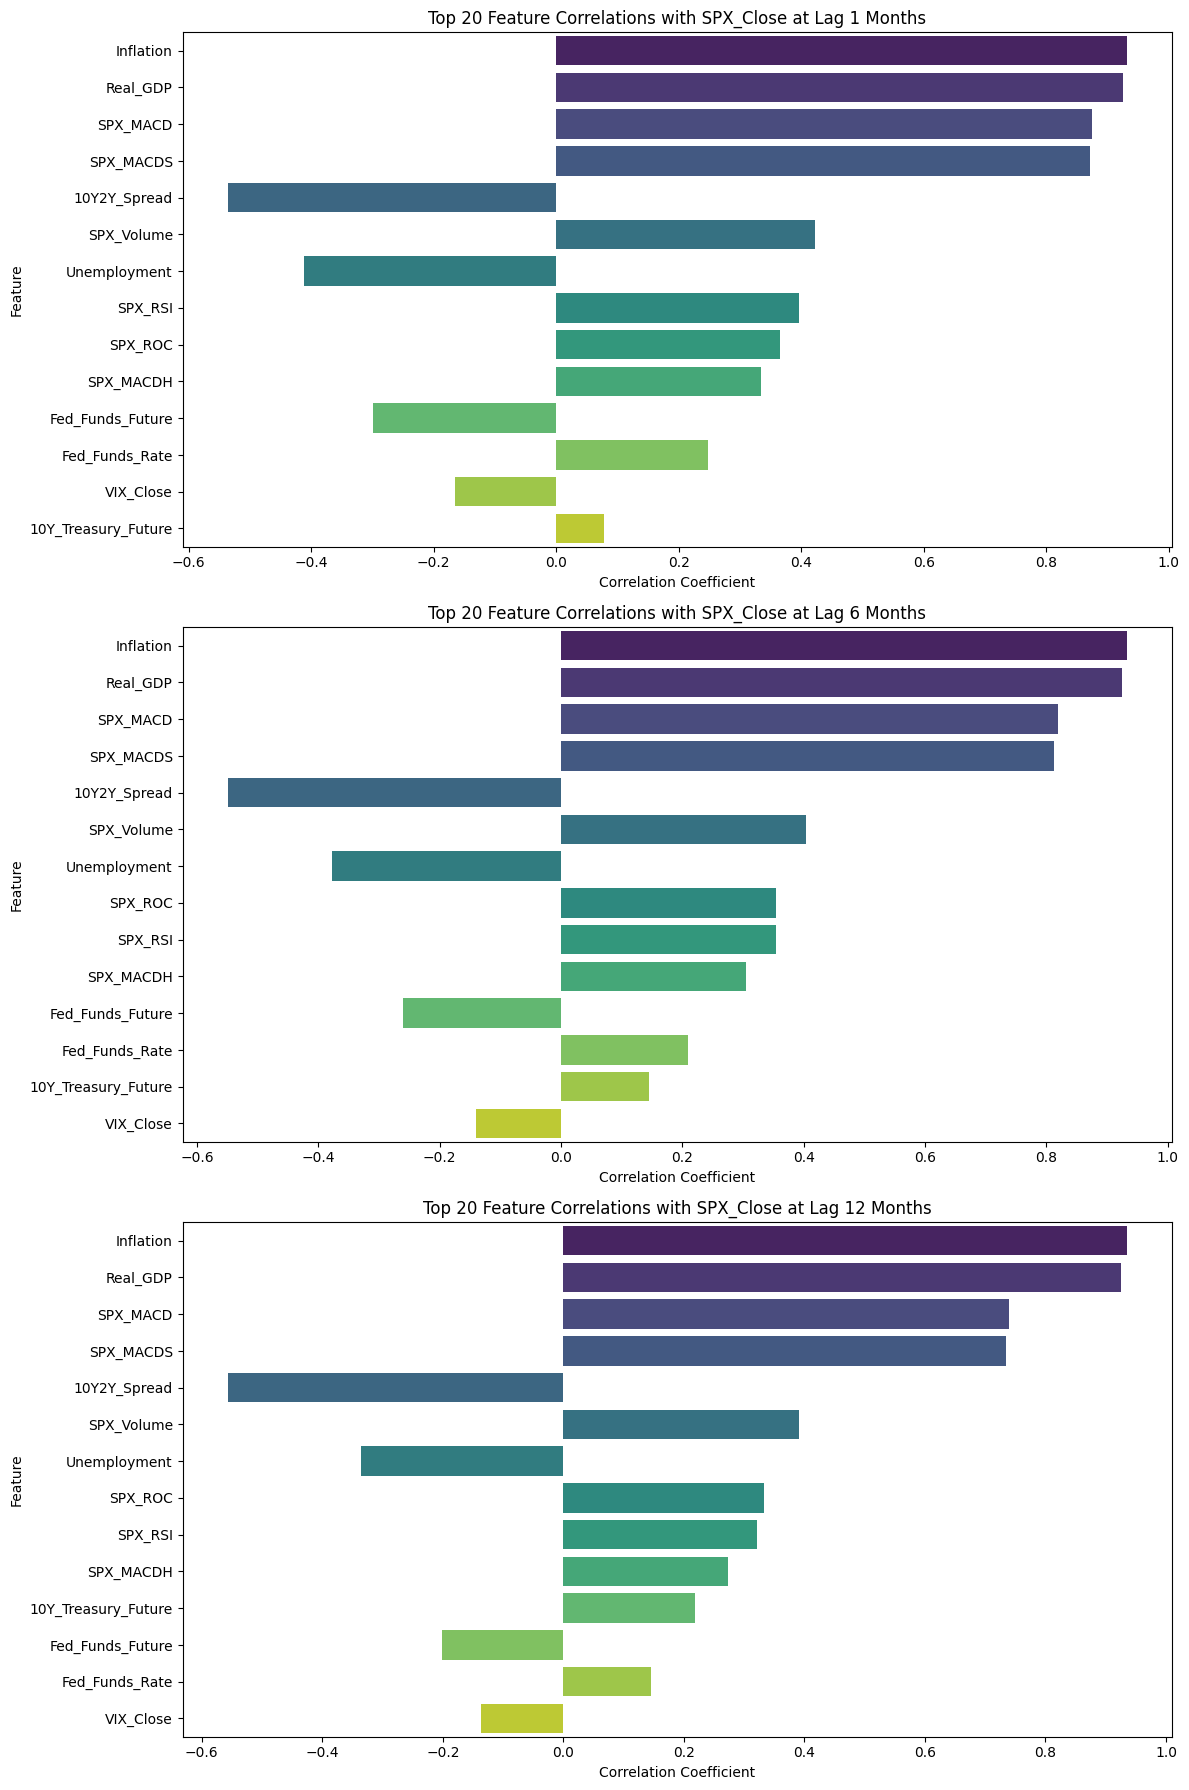

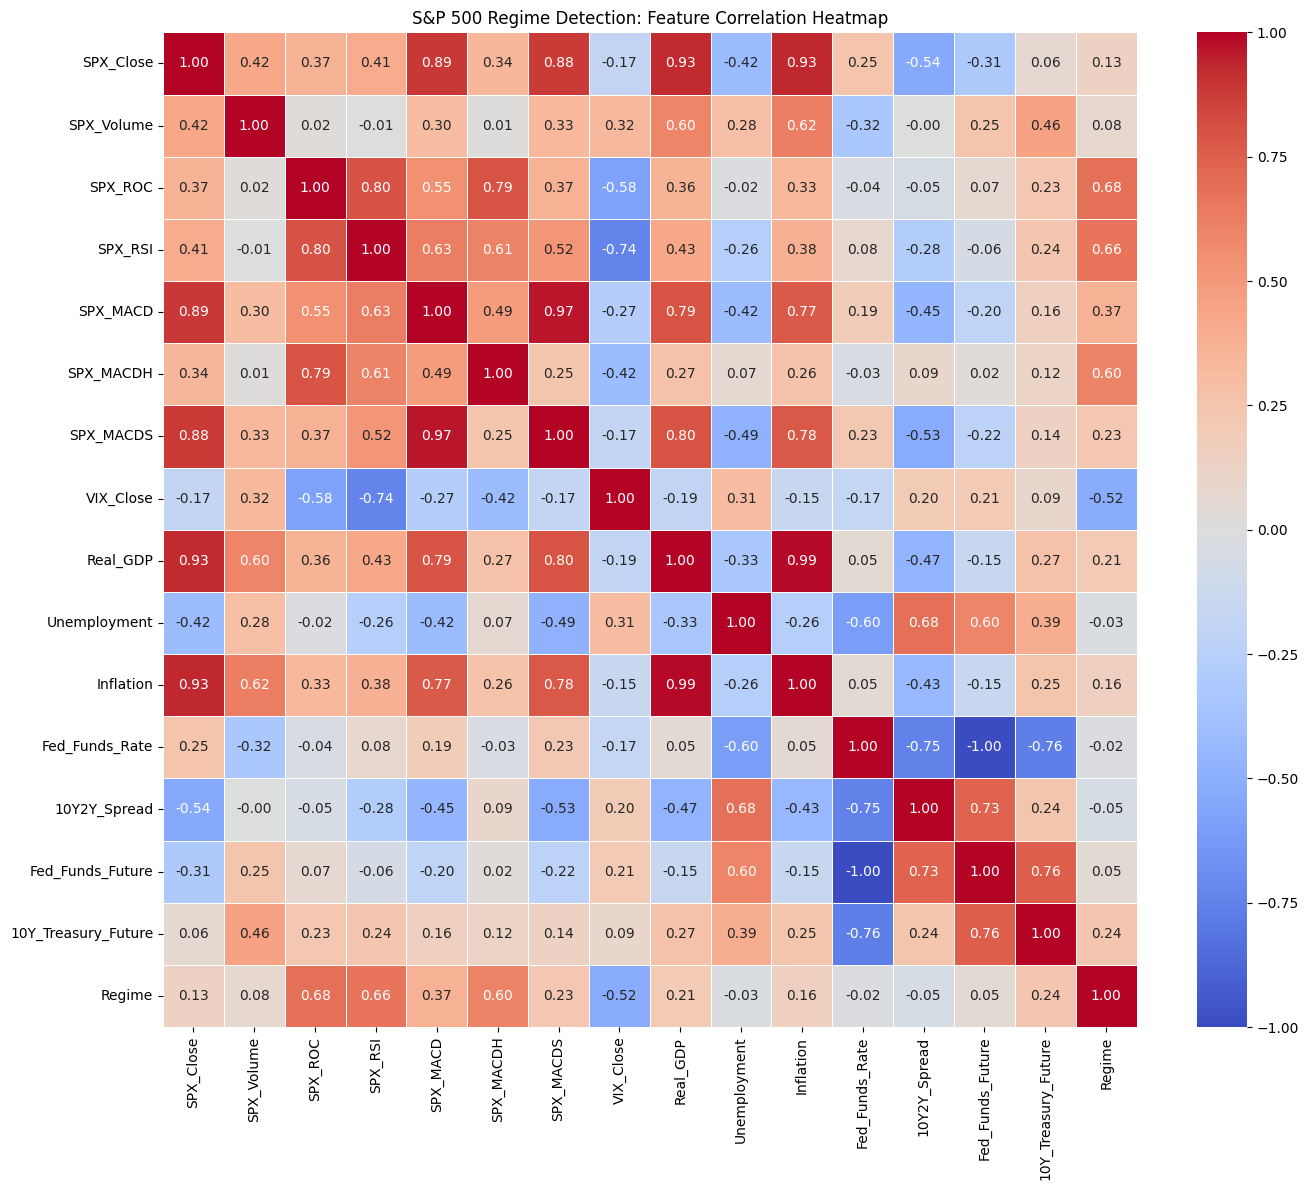

In [5]:
from analysis.scripts import feature_selection as fs

target_variable = "SPX_Close"
target = full_data_set[target_variable]
columns = [target_variable, "Regime"]
features = full_data_set.drop(columns=columns)
results_correlation = analysis_utils.calculate_feature_lagged_correlation(target, features, lags=[1, 6, 12])

analysis_utils.plot_correlation_ranking(results_correlation)

df_corr_m = fs.plot_correlation_heatmap(full_data_set)

In [6]:
high_corr_df , mod_corr_df = fs.extract_correlation_pairs(corr_matrix=df_corr_m, mod_low_bound=0.5, mod_up_bound=0.7, high_bound=0.7)
print("Highly Correlated DataFrame:")
print(high_corr_df)

print("\nModerately Correlated DataFrame:")
print(mod_corr_df)

Highly Correlated DataFrame:
              Feature_1         Feature_2  Correlation
0      Fed_Funds_Future    Fed_Funds_Rate    -0.999966
1             Inflation          Real_GDP     0.989760
2              SPX_MACD         SPX_MACDS     0.965326
3             Inflation         SPX_Close     0.931694
4              Real_GDP         SPX_Close     0.925536
5             SPX_Close          SPX_MACD     0.885095
6             SPX_Close         SPX_MACDS     0.881534
7               SPX_ROC           SPX_RSI     0.799807
8              Real_GDP         SPX_MACDS     0.796075
9             SPX_MACDH           SPX_ROC     0.790362
10             Real_GDP          SPX_MACD     0.789314
11            Inflation         SPX_MACDS     0.780850
12            Inflation          SPX_MACD     0.772112
13  10Y_Treasury_Future    Fed_Funds_Rate    -0.758002
14  10Y_Treasury_Future  Fed_Funds_Future     0.757722
15         10Y2Y_Spread    Fed_Funds_Rate    -0.747827
16              SPX_RSI         VIX_

### 2) Cleaning and Stationarity Testing

There are strong multicollinearity effects, where certain feature pairs exhibit high absolute correlations. Handling these redundancies ensures the machine learning model assigns correct predictive weights rather than getting confused by duplicated data.

- **Fed_Funds_Future** and **Fed_Funds_Rate** exhibit a near-perfect inverse correlation. Futures contracts are mathematically priced inversely to the expected target rate. Hence they relay the exact same information, so one must be dropped to prevent model instability.

- The high correlation between **SPX_MACD** and **SPX_MACDS** is purely mathematical. The signal line is simply a smoothed derivative of the MACD line:

  $$
  \text{SPX\_MACDS} = \text{EMA}_{9}(\text{SPX\_MACD})
  $$

  Feeding both into the algorithm duplicates the momentum signal. This identical mathematical redundancy explains the high correlation between **SPX_Close** and the technical indicators calculated directly from it.

- The 0.99 correlation between **Real_GDP** and **Inflation** is a spurious mathematical illusion caused by comparing raw, non-stationary data that naturally trends upward over decades. Because physical output and purchasing power are fundamentally distinct economic forces, we should not drop them. Instead, we must transform these absolute levels into stationary percentage rates of change:

  $$
  \Delta X_{t} = \frac{X_{t} - X_{t-1}}{X_{t-1}}
  $$


  **Actions from Correlaton heatmap**

- **Drop SPX_Close**: Raw prices are non-stationary and drift upward. Technical indicators (SPX_ROC, SPX_RSI, SPX_MACD) already solve this by normalizing price into stationary momentum signals.

- **Drop SPX_MACDS**: It is a mathematically redundant, lagging derivative of the core SPX_MACD signal.

- **Drop Fed_Funds_Future** since these contracts are fundamentally priced as an inverse of the expected target rate (Fed_Funds_Rate), meaning keeping both feeds the model the exact same information twice.

- **Transform Real_GDP and Inflation**: Convert both to stationary percentage rates of change to eliminate the spurious correlation caused by decades of natural upward drift. We must first confirm they are stationary with an **Augmented Dickey-Fuller test**.

In [7]:
# Drop the redundant and raw price columns
analysis_df = full_data_set.copy()
columns_to_drop = ['SPX_Close', 'SPX_MACDS', 'Fed_Funds_Future'] 
analysis_df = analysis_df.drop(columns=columns_to_drop)
print(analysis_df.isna().sum())

SPX_Volume              0
SPX_ROC                 0
SPX_RSI                 0
SPX_MACD                0
SPX_MACDH               0
VIX_Close               0
Real_GDP                0
Unemployment            0
Inflation               0
Fed_Funds_Rate          0
10Y2Y_Spread            0
10Y_Treasury_Future    52
Regime                  0
dtype: int64


**Dropping 10Y_Treasury_Future**

The 10Y_Treasury_Future feature contains 95 missing values, representing about 4 years of data. Models like Logistic Regression require a complete square datasets, keeping this single feature would force us to delete 52 rows. from each column. Hence,  to preserve the full 312-month history of key features, we drop the column 10Y_Treasury_Future.

In [8]:
analysis_df = analysis_df.drop(columns='10Y_Treasury_Future')

**Stationarity Testing**

In [9]:
""""
null hypothesis assumes that your column of data is completely non-stationary.
Therefore,a p-value under 0.05 gives us 95% confidence the data is stationary (trend-free).
"""
fs.run_adf_test(analysis_df)

Augmented Dickey-Fuller Stationarity Test Results:

[NON-STATIONARY] SPX_Volume (p-value: 0.3944)
[STATIONARY]     SPX_ROC (p-value: 0.0010)
[STATIONARY]     SPX_RSI (p-value: 0.0299)
[NON-STATIONARY] SPX_MACD (p-value: 0.8662)
[STATIONARY]     SPX_MACDH (p-value: 0.0000)
[STATIONARY]     VIX_Close (p-value: 0.0000)
[NON-STATIONARY] Real_GDP (p-value: 0.9850)
[STATIONARY]     Unemployment (p-value: 0.0362)
[NON-STATIONARY] Inflation (p-value: 0.9988)
[STATIONARY]     Fed_Funds_Rate (p-value: 0.0012)
[STATIONARY]     10Y2Y_Spread (p-value: 0.0162)
[STATIONARY]     Regime (p-value: 0.0023)


**Tackling non-stationarity**

Real_GDP, Inflation (CPI index), and SPX_Volume these are unbound values that compound over time. Hence, **percentage change** "scales" the move relative to previous in data point in time series.

Fed_Funds_Rate, 10Y2Y_Spread, SPX_MACD and inflation are already express in basis points. Thus, applying a percentage to a percentage  will create noise. Therefore, applying **first difference** instead.


In [10]:
# Create a fresh version for stationarity transformations
processed_df = analysis_df.copy()

# Percentage Change
processed_df['Real_GDP'] = processed_df['Real_GDP'].pct_change()
processed_df['Inflation'] = processed_df['Inflation'].pct_change()
processed_df['SPX_Volume'] = processed_df['SPX_Volume'].pct_change()

# First Difference
# Fed_Funds_Rate and 10Y2Y_Spread are already stationary
processed_df['SPX_MACD'] = processed_df['SPX_MACD'].diff()
# We need this because simply pct_changing inflation still yields non-stationary series
# The inflation feature essentially becomes "inflation acceleration"
processed_df['Inflation'] = processed_df['Inflation'].diff()

# Replaces any 'inf' (infinity) with NaN so they can be dropped
processed_df = processed_df.replace([np.inf, -np.inf], np.nan)

processed_df.shape

(312, 12)

In [11]:
fs.run_adf_test(processed_df)

Augmented Dickey-Fuller Stationarity Test Results:

[STATIONARY]     SPX_Volume (p-value: 0.0000)
[STATIONARY]     SPX_ROC (p-value: 0.0010)
[STATIONARY]     SPX_RSI (p-value: 0.0299)
[STATIONARY]     SPX_MACD (p-value: 0.0000)
[STATIONARY]     SPX_MACDH (p-value: 0.0000)
[STATIONARY]     VIX_Close (p-value: 0.0000)
[STATIONARY]     Real_GDP (p-value: 0.0000)
[STATIONARY]     Unemployment (p-value: 0.0362)
[STATIONARY]     Inflation (p-value: 0.0000)
[STATIONARY]     Fed_Funds_Rate (p-value: 0.0012)
[STATIONARY]     10Y2Y_Spread (p-value: 0.0162)
[STATIONARY]     Regime (p-value: 0.0023)


In [12]:
processed_df.dropna()

,SPX_Volume,SPX_ROC,SPX_RSI,SPX_MACD,SPX_MACDH,VIX_Close,Real_GDP,Unemployment,Inflation,Fed_Funds_Rate,10Y2Y_Spread,Regime
2000-03-01,0.250775,16.496806,68.453284,4.167039,-2.863535,24.110001,0.000000,4.0,0.000589,5.85,-0.13,1.0
2000-04-01,-0.231293,8.781587,64.160327,-1.813454,-3.741592,26.200001,0.018213,3.8,-0.001399,6.02,-0.13,1.0
2000-05-01,-0.010353,9.122474,61.304661,-5.336038,-7.262103,23.650000,0.000000,4.0,0.000415,6.27,-0.44,1.0
2000-06-01,0.092470,5.965573,63.189352,-2.783685,-8.036630,19.540001,0.000000,4.0,-0.000309,6.53,-0.41,1.0
2000-07-01,-0.121868,7.684839,60.954134,-5.360690,-10.717856,20.740000,0.001019,4.0,0.001524,6.54,-0.41,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,-0.128528,14.373272,71.301868,18.942877,26.192304,15.360000,0.000000,4.3,-0.000204,4.33,0.54,1.0
2025-09-01,0.148186,16.069123,73.849586,28.038674,43.384782,16.280001,0.000000,4.4,-0.000352,4.22,0.54,1.0
2025-10-01,0.136639,19.888877,75.412657,28.746110,57.704714,17.440001,0.001628,4.4,0.000398,4.09,0.57,1.0
2025-11-01,-0.221974,13.538769,75.505030,17.577291,60.225604,16.350000,0.000000,4.5,-0.000500,3.88,0.57,1.0


# III) Experiment 1 (Using All Features \& Holdout Validation)

### 1) Setup and Model Training

We initially use 80%-20% train-test split of the time series data. This results in a single holdout test set. We train three models:
- Logistic Regression
- Random Forest
- Gradient Boosting
Financial markets natively trend upward, resulting in a heavily imbalanced dataset. Without intervention, a model can achieve 80% accuracy simply by guessing "Bull" every single time. By applying balanced sample weights, we mathematically forced the models to penalize "Bear" misclassifications heavily.

In [13]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight

# Global Styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 130,
    "font.family": "sans-serif",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

PALETTE = {
    "fed":    "#e73ce4",   
    "macro":  "#e67e22",   
    "tech":   "#3498db",   
    "pos":    "#2ecc71",   
    "neg":    "#e74c3c",   
}

FEATURE_COLS = [
    "SPX_Volume", "SPX_ROC", "SPX_RSI",
    "SPX_MACD", "SPX_MACDH",
    "VIX_Close",
    "Real_GDP", "Unemployment", "Inflation",
    "Fed_Funds_Rate", "10Y2Y_Spread",
]
MACRO_FEATURES = {"Real_GDP", "Unemployment", "Inflation", "Fed_Funds_Rate", "10Y2Y_Spread", "Fed_Funds_Future", "10Y_Treasury_Future"}

full_data = processed_df.dropna().copy()
X = full_data[FEATURE_COLS]
y = full_data["Regime"]

# Chronological train/test split (80/20)
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_COLS, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURE_COLS, index=X_test.index)

print(f"Train: {len(X_train)} months | Test: {len(X_test)} months")
print(f"Train balance — Bull: {int((y_train==1).sum())} Bear: {int((y_train==0).sum())}")
print(f"Test balance — Bull: {int((y_test==1).sum())} Bear: {int((y_test==0).sum())}")

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42),
}

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train, sample_weight=sample_weights)
    preds = model.predict(X_test_s)
    acc = accuracy_score(y_test, preds)
    results[name] = {"model": model, "preds": preds, "accuracy": acc}
    
    print(f"\n{'─'*50}")
    print(f"  {name}  —  Accuracy: {acc:.2%}")
    print(f"{'─'*50}")
    print(classification_report(y_test, preds, target_names=["Bear", "Bull"], zero_division=0))


Train: 248 months | Test: 62 months
Train balance — Bull: 208 Bear: 40
Test balance — Bull: 50 Bear: 12

──────────────────────────────────────────────────
  Logistic Regression  —  Accuracy: 98.39%
──────────────────────────────────────────────────
              precision    recall  f1-score   support

        Bear       1.00      0.92      0.96        12
        Bull       0.98      1.00      0.99        50

    accuracy                           0.98        62
   macro avg       0.99      0.96      0.97        62
weighted avg       0.98      0.98      0.98        62


──────────────────────────────────────────────────
  Random Forest  —  Accuracy: 83.87%
──────────────────────────────────────────────────
              precision    recall  f1-score   support

        Bear       1.00      0.17      0.29        12
        Bull       0.83      1.00      0.91        50

    accuracy                           0.84        62
   macro avg       0.92      0.58      0.60        62
weighted av

### 2) Feature Importance / Coefficient Magnitude

Random Forest / Gradient Boosting provide robust, non-linear feature importances using Mean Decrease in Impurity.

Logistic Regression shows linear relationships. We rank by absolute coefficient magnitude.


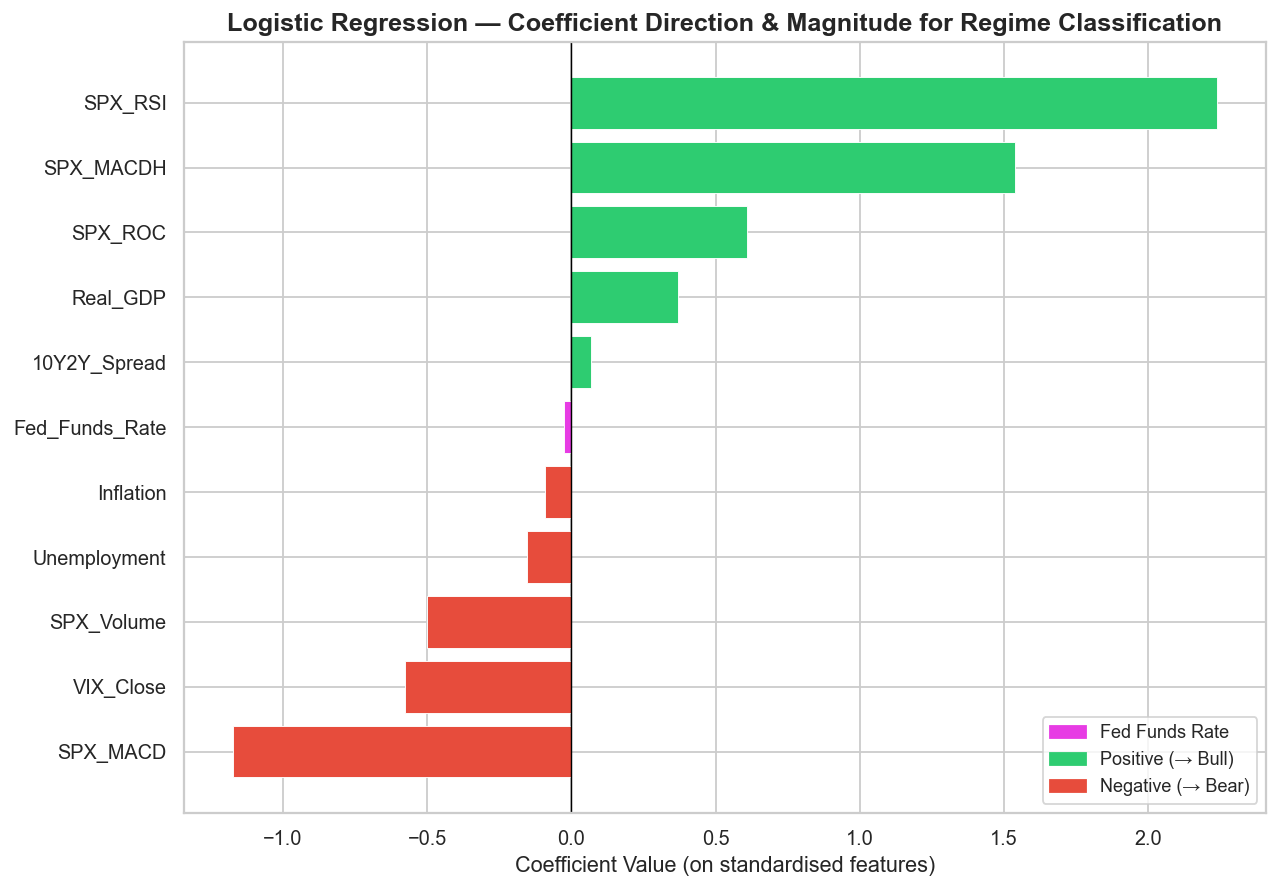

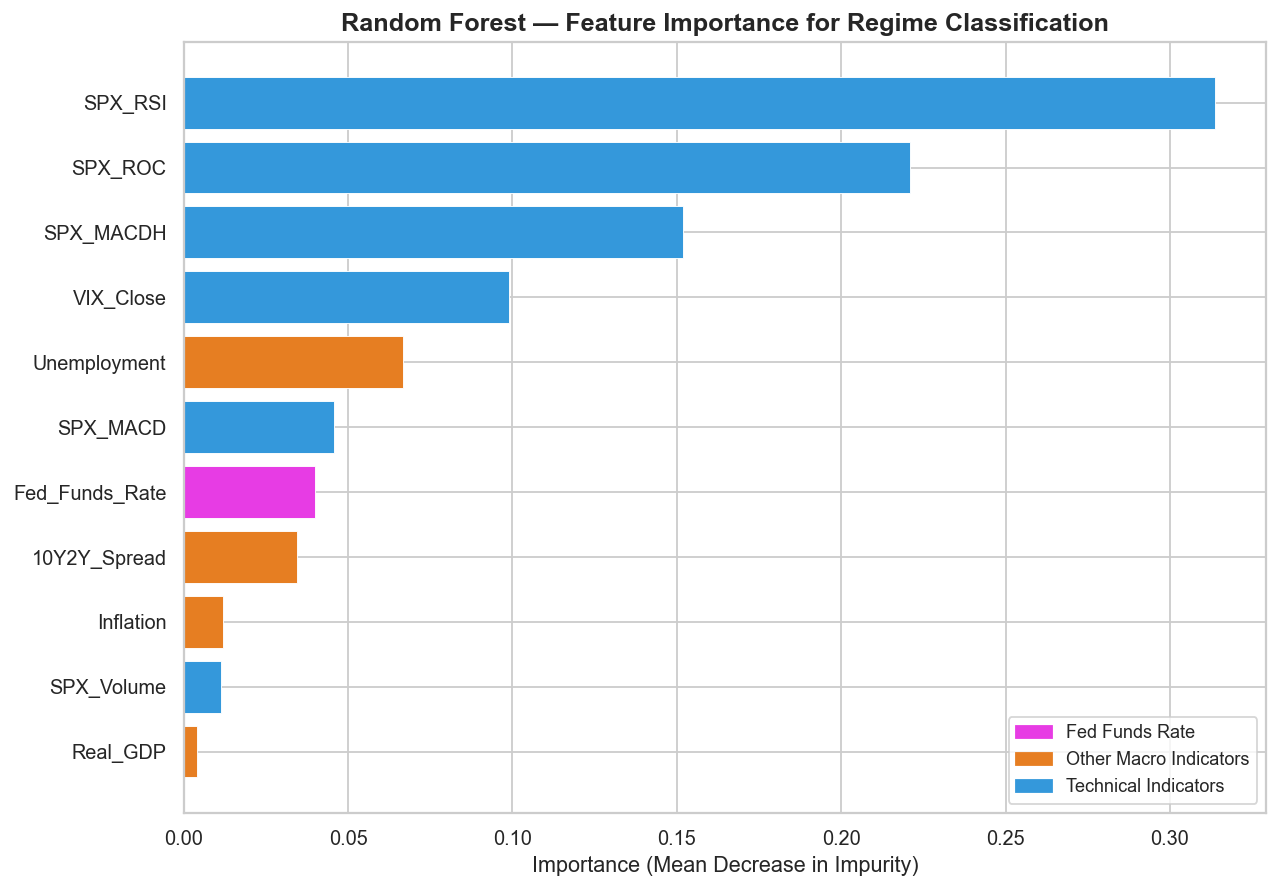

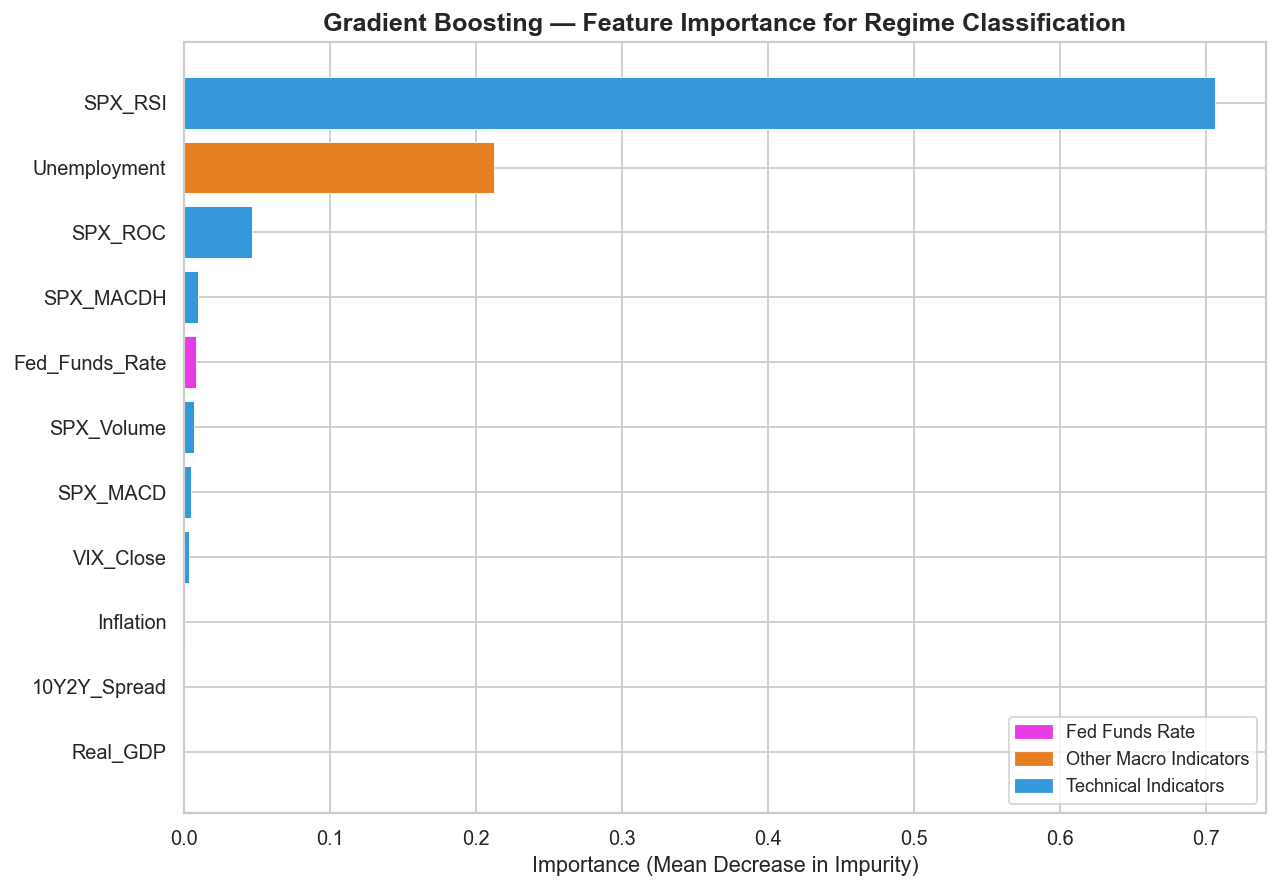

  CROSS-MODEL CONSENSUS: Fed Funds Rate Ranking
  Logistic Regression :  #11 / 11
  Random Forest       :  #7 / 11
  Gradient Boosting   :  #5 / 11

  Average Rank: 7.7 / 11


In [14]:
def feature_color(name):
    if "Fed_Funds_Rate" in name: 
        return PALETTE["fed"]
    if any(macro_base in name for macro_base in MACRO_FEATURES): 
        return PALETTE["macro"]
    return PALETTE["tech"]

legend_handles = [
    mpatches.Patch(color=PALETTE["fed"],   label="Fed Funds Rate"),
    mpatches.Patch(color=PALETTE["macro"], label="Other Macro Indicators"),
    mpatches.Patch(color=PALETTE["tech"],  label="Technical Indicators"),
]

# Coefficient Magnitude for Logistic Regression
lr = results["Logistic Regression"]["model"]
coefs = pd.Series(lr.coef_[0], index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(10, 7))
colors = [PALETTE["fed"] if f == "Fed_Funds_Rate" else (PALETTE["pos"] if v > 0 else PALETTE["neg"]) for f, v in zip(coefs.index, coefs.values)]
ax.barh(coefs.index, coefs.values, color=colors, edgecolor="white", linewidth=0.5)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient Value (on standardised features)")
ax.set_title("Logistic Regression — Coefficient Direction & Magnitude for Regime Classification")
coef_legend = [
    mpatches.Patch(color=PALETTE["fed"], label="Fed Funds Rate"),
    mpatches.Patch(color=PALETTE["pos"], label="Positive (→ Bull)"),
    mpatches.Patch(color=PALETTE["neg"], label="Negative (→ Bear)"),
]
ax.legend(handles=coef_legend, loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

# Random Forest Feature Importance
rf = results["Random Forest"]["model"]
imp_rf = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_rf.index, imp_rf.values, color=[feature_color(f) for f in imp_rf.index], edgecolor="white", linewidth=0.5)
ax.set_xlabel("Importance (Mean Decrease in Impurity)")
ax.set_title("Random Forest — Feature Importance for Regime Classification")
ax.legend(handles=legend_handles, loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

# Gradient Boosting Feature Importance
gb = results["Gradient Boosting"]["model"]
imp_gb = pd.Series(gb.feature_importances_, index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_gb.index, imp_gb.values, color=[feature_color(f) for f in imp_gb.index], edgecolor="white", linewidth=0.5)
ax.set_xlabel("Importance (Mean Decrease in Impurity)")
ax.set_title("Gradient Boosting — Feature Importance for Regime Classification")
ax.legend(handles=legend_handles, loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

# Cross-model consensus
rf_rank  = (imp_rf.sort_values(ascending=False).index.tolist().index("Fed_Funds_Rate")) + 1
gb_rank  = (imp_gb.sort_values(ascending=False).index.tolist().index("Fed_Funds_Rate")) + 1
abs_coefs = coefs.abs().sort_values(ascending=False)
lr_rank  = (abs_coefs.index.tolist().index("Fed_Funds_Rate")) + 1

print("=" * 60)
print("  CROSS-MODEL CONSENSUS: Fed Funds Rate Ranking")
print("=" * 60)
print(f"  Logistic Regression :  #{lr_rank} / {len(FEATURE_COLS)}")
print(f"  Random Forest       :  #{rf_rank} / {len(FEATURE_COLS)}")
print(f"  Gradient Boosting   :  #{gb_rank} / {len(FEATURE_COLS)}")
avg_rank = (rf_rank + gb_rank + lr_rank) / 3
print(f"\n  Average Rank: {avg_rank:.1f} / {len(FEATURE_COLS)}")
print("=" * 60)

### 3) Interpretation

From these initial results, it seems like the Fed Funds Rate is a contributing factor to regime identification, but it is not the primary trigger. The market's own momentum signals (RSI, ROC) and volatility (VIX) seem to be stronger predictors of when the S&P 500 transitions between bull and bear regimes.

# IV) Experiment 2 (Lags, Deltas, Monthly Resampling)

**Monthly Resampling**

In the initial approach, we combined daily technical indicators (like RSI and MACD) with macroeconomic data (like the Fed Funds Rate) into a single daily dataset. This may have introduced a structural flaw because of the mismatch in timeframes for these features: technical indicators update every single day, while the Fed Rate can change  roughly once every six weeks (when the Fed meets), meaning its column in our dataset is essentially a flat line 98% of the time. 

Tree-based models (like Random Forest and Gradient Boosting) are biased to favour continuous variables with high variance because it gives them more opportunities to split the data. By down-sampling our entire dataset to a Month-End (ME) frequency, we reduce the daily noise coming from technical indicators. This forces the models to evaluate macroeconomic data and technical data on a more balanced playing field.

**Lags \& Deltas**

Feeding the model only the current absolute Fed rate limits predictive power because monetary policy does not affect the real economy instantly.

More formally, we define two hypotheses:

- **Hypothesis 1** (Delayed Impact): Monetary policy acts with "long and variable lags." A rate hike today doesn't instantly crash the market; it takes months for the higher borrowing costs to drain liquidity, squeeze corporate margins, and trigger a Bear market. Therefore, today's market regime is heavily influenced by past policy levels.
  
- **Hypothesis 2**: The absolute level of the Fed rate (e.g., 5%) is less defining for the market than the velocity and direction of its recent changes. A sudden, ra pid hiking cycle shocks the financial system much harder than a rate that has been sitting high for years.

To test these, we engineer backward-looking features to capture both the delay and the momentum of the macroeconomic data:

- **Lags**: Where was the Fed rate 3, 6, and 12 months ago? This allows the model to map how past policy decisions (from months ago) manifest into today's market regime.

- **Deltas (Momentum)**: How fast did the Fed hike or cut rates over the trailing 3, 6, and 12 months? This calculates the rate of change, allowing the model to detect the "shock" of rapid policy shifts.


### 1) Setup and Model Training

The setup and models are the same as above with a holdout test set. However, we notice that by adding multiple lags and deltas for our macro indicators, we also introduced **mutlicollinearity**. For example, the 3-month lag and 6-month lag of the Fed rate carry highly overlapping information.

If we feed highly correlated features into our models:
- Tree models might randomly split their "importance votes" across the overlapping features, artificially diluting the rank of the underlying metric.
- Linear models might destabilize, assigning erratic positive and negative weights to cancel the features out.

To solve this, we apply an **L1 Penalty** to our Logistic Regression model. L1 regularization forces redundant features to exactly 0. We then extract only the "surviving" non-zero features (a pruned dataset of 11 indicators) and feed them back into our tree models for a cleaner evaluation.

Train: 238 months | Test: 60 months
Train balance — Bull: 198 Bear: 40
Test balance — Bull: 48 Bear: 12

──────────────────────────────────────────────────
  Logistic Regression  —  Accuracy: 80.00%
──────────────────────────────────────────────────
              precision    recall  f1-score   support

        Bear       0.00      0.00      0.00        12
        Bull       0.80      1.00      0.89        48

    accuracy                           0.80        60
   macro avg       0.40      0.50      0.44        60
weighted avg       0.64      0.80      0.71        60



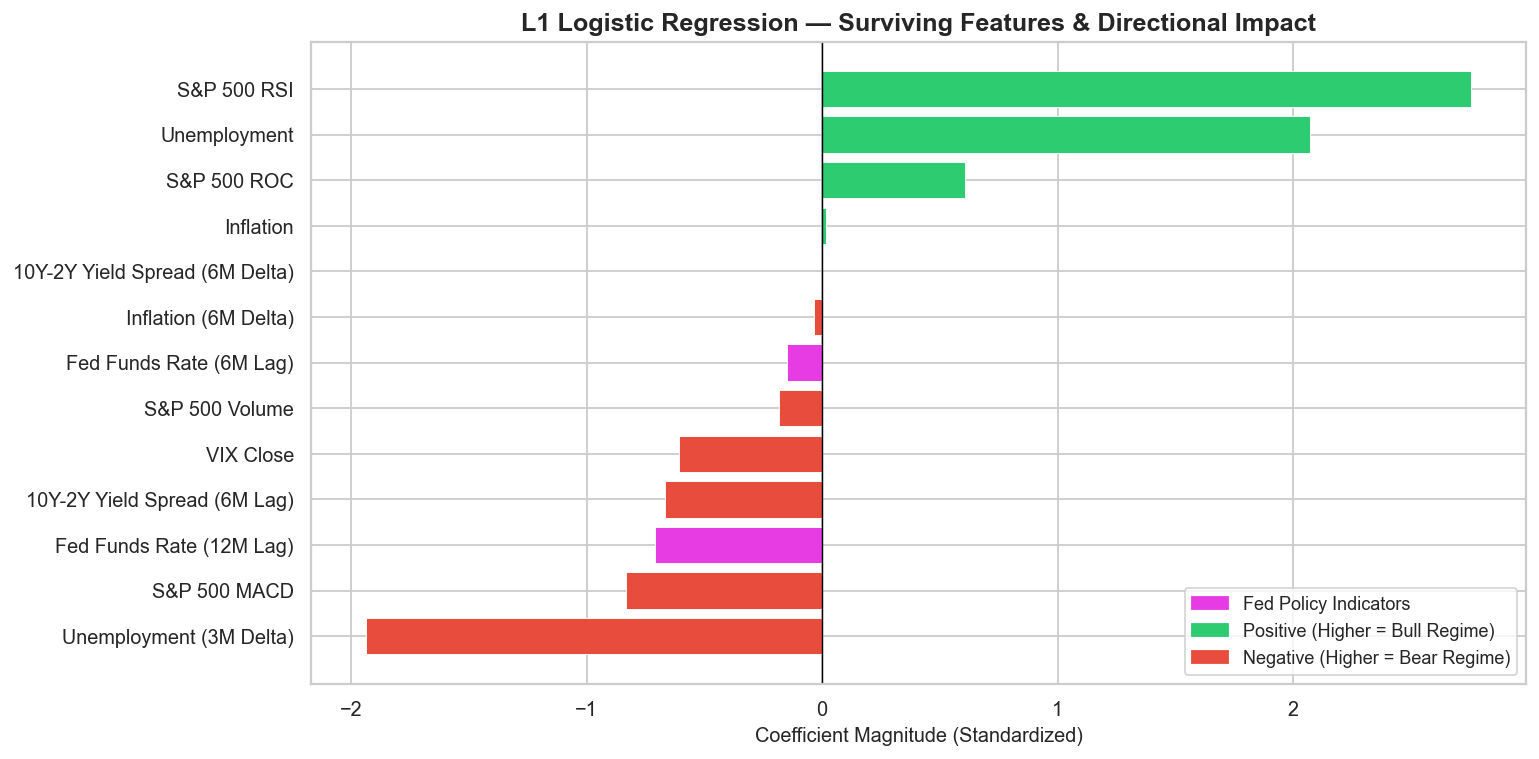

In [15]:
# Resample to Monthly frequency first
monthly_data = processed_df.resample('ME').last()

MACRO_FULL = ["Fed_Funds_Rate", "10Y2Y_Spread"] # Gets Lags AND Deltas
MACRO_DELTA_ONLY = ["Inflation", "Unemployment"] # Gets Deltas ONLY
MACRO_RAW = ["Real_GDP"] # No Lags or Deltas

# Produce lagged features
ENGINEERED_MACRO = []
for col in MACRO_FULL:
    monthly_data[f'{col}_Lag3M'] = monthly_data[col].shift(3)
    monthly_data[f'{col}_Lag6M'] = monthly_data[col].shift(6)
    monthly_data[f'{col}_Lag12M'] = monthly_data[col].shift(12)
    monthly_data[f'{col}_Delta3M'] = monthly_data[col] - monthly_data[f'{col}_Lag3M']
    monthly_data[f'{col}_Delta6M'] = monthly_data[col] - monthly_data[f'{col}_Lag6M']
    monthly_data[f'{col}_Delta12M'] = monthly_data[col] - monthly_data[f'{col}_Lag12M']
    ENGINEERED_MACRO.extend([f'{col}_Lag3M', f'{col}_Lag6M', f'{col}_Lag12M', f'{col}_Delta3M', f'{col}_Delta6M', f'{col}_Delta12M'])
for col in MACRO_DELTA_ONLY:
    lag3 = monthly_data[col].shift(3)
    lag6 = monthly_data[col].shift(6)
    lag12 = monthly_data[col].shift(12)
    monthly_data[f'{col}_Delta3M'] = monthly_data[col] - lag3
    monthly_data[f'{col}_Delta6M'] = monthly_data[col] - lag6
    monthly_data[f'{col}_Delta12M'] = monthly_data[col] - lag12
    ENGINEERED_MACRO.extend([col, f'{col}_Delta3M', f'{col}_Delta6M', f'{col}_Delta12M'])

# Add the Raw Macro directly to the feature list
ENGINEERED_MACRO.extend(MACRO_RAW)

monthly_data = monthly_data.dropna().copy()

FEATURE_COLS = [
    "SPX_Volume", "SPX_ROC", "SPX_RSI", "SPX_MACD", "SPX_MACDH", "VIX_Close"
] + ENGINEERED_MACRO

X = monthly_data[FEATURE_COLS]
y = monthly_data["Regime"]

# Chronological train/test split (80/20)
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_COLS, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURE_COLS, index=X_test.index)

print(f"Train: {len(X_train)} months | Test: {len(X_test)} months")
print(f"Train balance — Bull: {int((y_train==1).sum())} Bear: {int((y_train==0).sum())}")
print(f"Test balance — Bull: {int((y_test==1).sum())} Bear: {int((y_test==0).sum())}")

# L1 penalty with logistic regression for feature selection
results = {}
name = "Logistic Regression"
model = LogisticRegression(l1_ratio=1, solver="liblinear", max_iter=2000, random_state=42)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
model.fit(X_train_s, y_train, sample_weight=sample_weights)
preds = model.predict(X_test_s)
acc = accuracy_score(y_test, preds)
results[name] = {"model": model, "preds": preds, "accuracy": acc}
print(f"\n{'─'*50}")
print(f"  {name}  —  Accuracy: {acc:.2%}")
print(f"{'─'*50}")
print(classification_report(y_test, preds, target_names=["Bear", "Bull"], zero_division=0))

# Plot surviving features after l1 penalisation (in logistic regression) and their impact
lr = results["Logistic Regression"]["model"]
coefs = pd.Series(lr.coef_[0], index=FEATURE_COLS)

coefs = coefs[coefs != 0].sort_values()

# Clean up the feature names for the chart
def clean_feature_name(name):
    name = name.replace("_", " ")
    name = name.replace("Lag3M", "(3M Lag)")
    name = name.replace("Lag6M", "(6M Lag)")
    name = name.replace("Lag12M", "(12M Lag)")
    name = name.replace("Delta3M", "(3M Delta)")
    name = name.replace("Delta6M", "(6M Delta)")
    name = name.replace("Delta12M", "(12M Delta)")
    name = name.replace("10Y2Y Spread", "10Y-2Y Yield Spread")
    name = name.replace("SPX", "S&P 500")
    return name

clean_labels = [clean_feature_name(f) for f in coefs.index]

fig_height = max(6, len(coefs) * 0.4) 
fig, ax = plt.subplots(figsize=(12, fig_height))

colors = [
    PALETTE["fed"] if "Fed Funds Rate" in f else (PALETTE["pos"] if v > 0 else PALETTE["neg"]) 
    for f, v in zip(clean_labels, coefs.values)
]
ax.barh(clean_labels, coefs.values, color=colors, edgecolor="white", linewidth=0.5)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient Magnitude (Standardized)", fontsize=11)
ax.set_title("L1 Logistic Regression — Surviving Features & Directional Impact", fontweight="bold", fontsize=14)
coef_legend = [
    mpatches.Patch(color=PALETTE["fed"], label="Fed Policy Indicators"),
    mpatches.Patch(color=PALETTE["pos"], label="Positive (Higher = Bull Regime)"),
    mpatches.Patch(color=PALETTE["neg"], label="Negative (Higher = Bear Regime)"),
]
ax.legend(handles=coef_legend, loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

### 2) Train Tree Models with Pruned Features

We slightly modify the parameters of the tree-based models to adapt to the likely reduction in the number of features caused by the L1 penalty. We focus specifically on shallower trees and add an asymmetric decision boundary or "probability threshold" requiring a strict 90% confidence for bull regimes to further counteract the market's natural upward bias.

In [16]:
# Train tree-based models on pruned features

# Filter for features where the coefficient is not exactly zero
selected_features = coefs[coefs != 0].index.tolist()

print("=" * 60)
print("L1 FEATURE SELECTION SUMMARY")
print("=" * 60)
print(f" Original feature count : {len(FEATURE_COLS)}")
print(f" Pruned feature count   : {len(selected_features)}")
print(f" Eliminated             : {len(FEATURE_COLS) - len(selected_features)} features")
print("-" * 60)
print(" Features Kept:")
for feat in selected_features:
    print(f"  {feat}")
print("=" * 60)

# Create newly filtered DataFrames for training and testing
X_train_pruned = X_train_s[selected_features]
X_test_pruned  = X_test_s[selected_features]

# Retrain the Tree Models on the pruned set of features
models_pruned = {
    "Random Forest (Pruned)": RandomForestClassifier(n_estimators=300, max_depth=3, random_state=42),
    "Gradient Boosting (Pruned)": GradientBoostingClassifier(n_estimators=75, max_depth=2, learning_rate=0.05, random_state=42),
}

results_pruned = {}
print("\nRETRAINING TREE MODELS ON PRUNED DATASET...")
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
for name, model in models_pruned.items():
    model.fit(X_train_pruned, y_train, sample_weight=sample_weights)
    threshold = 0.5 if name == "Logistic Regression" else 0.9
    probs = model.predict_proba(X_test_pruned)
    prob_bull = probs[:, 1]
    custom_preds = (prob_bull >= threshold).astype(int)
    acc = accuracy_score(y_test, custom_preds)
    results_pruned[name] = {"model": model, "preds": custom_preds, "accuracy": acc}
    print(f"\n{'─'*50}")
    print(f"  {name}  —  Accuracy (Threshold {threshold}): {acc:.2%}")
    print(f"{'─'*50}")
    print(classification_report(y_test, custom_preds, target_names=["Bear", "Bull"], zero_division=0))



L1 FEATURE SELECTION SUMMARY
 Original feature count : 27
 Pruned feature count   : 13
 Eliminated             : 14 features
------------------------------------------------------------
 Features Kept:
  Unemployment_Delta3M
  SPX_MACD
  Fed_Funds_Rate_Lag12M
  10Y2Y_Spread_Lag6M
  VIX_Close
  SPX_Volume
  Fed_Funds_Rate_Lag6M
  Inflation_Delta6M
  10Y2Y_Spread_Delta6M
  Inflation
  SPX_ROC
  Unemployment
  SPX_RSI

RETRAINING TREE MODELS ON PRUNED DATASET...

──────────────────────────────────────────────────
  Random Forest (Pruned)  —  Accuracy (Threshold 0.9): 75.00%
──────────────────────────────────────────────────
              precision    recall  f1-score   support

        Bear       0.43      0.75      0.55        12
        Bull       0.92      0.75      0.83        48

    accuracy                           0.75        60
   macro avg       0.68      0.75      0.69        60
weighted avg       0.82      0.75      0.77        60


───────────────────────────────────────────

### 3) Feature Importance (Pruned Features)

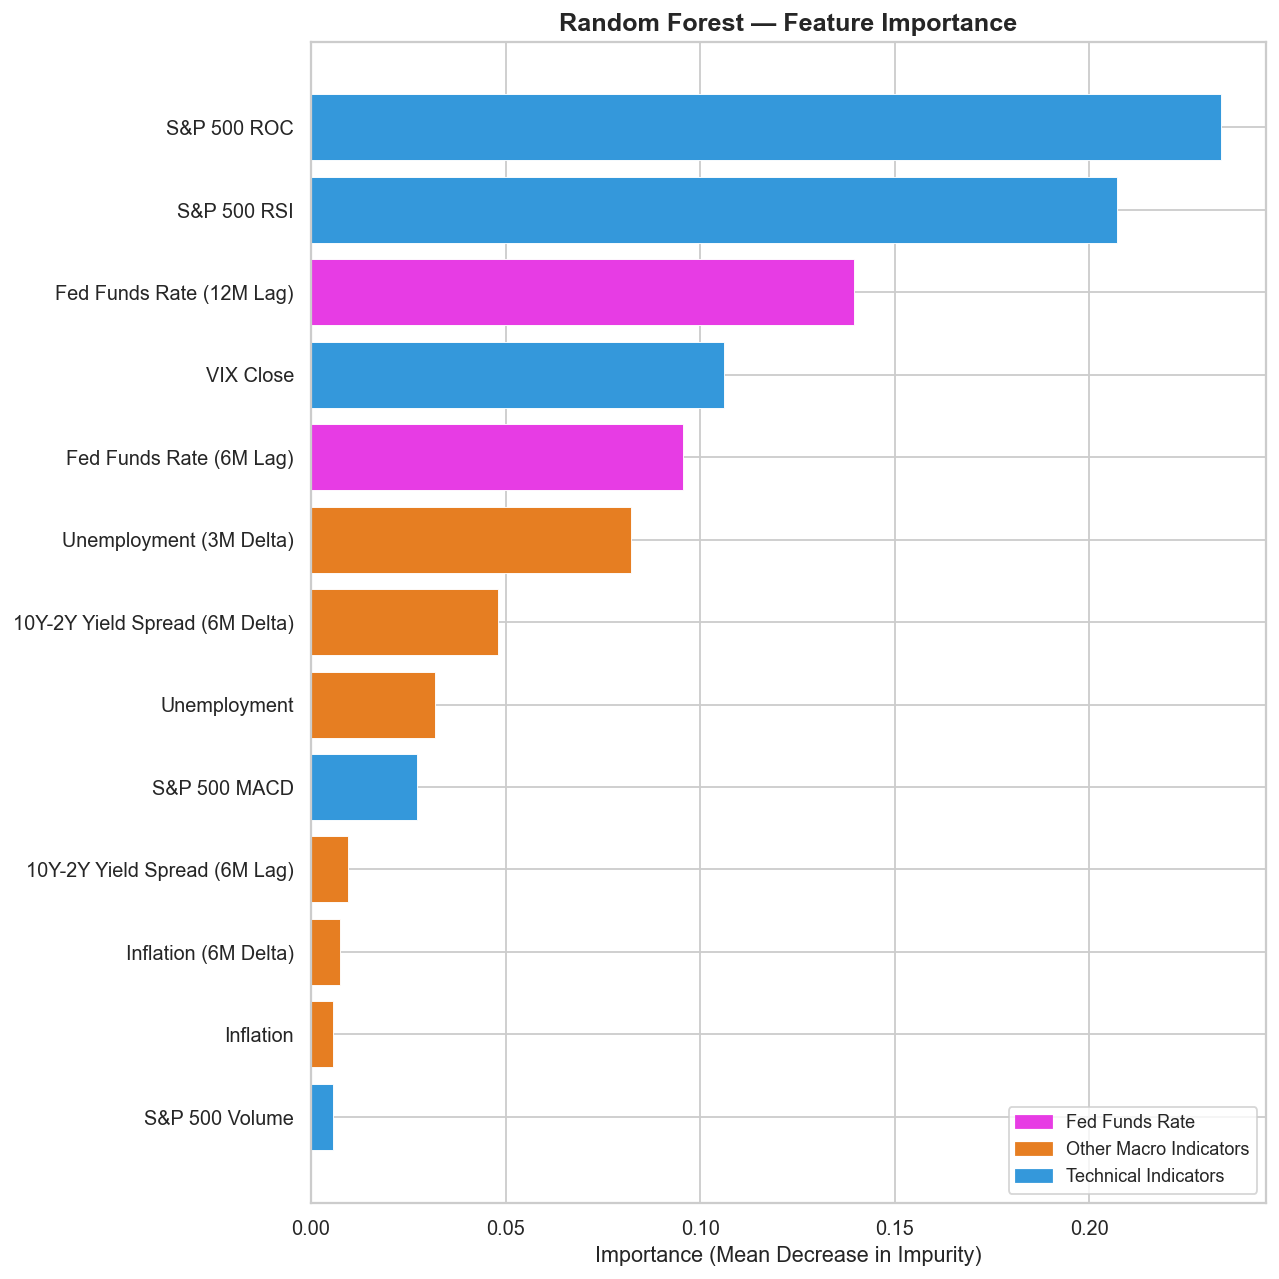

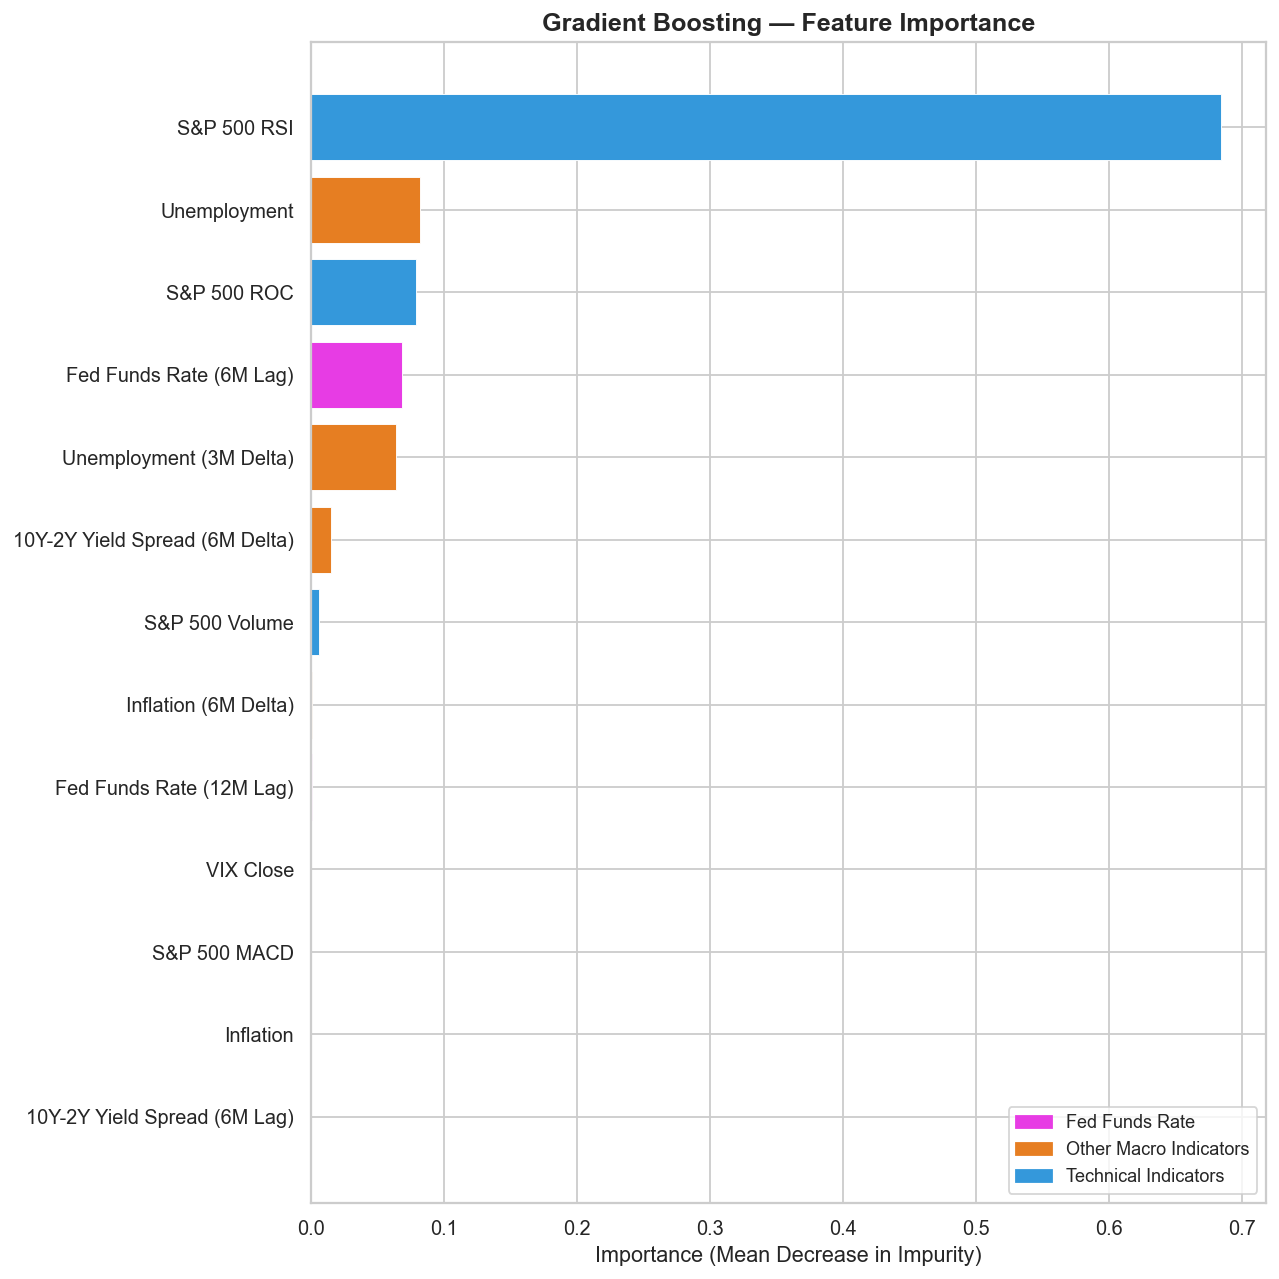

  CROSS-MODEL CONSENSUS: Best Fed Policy Indicator Ranking
  Logistic Regression :  #5 / 27
  Random Forest       :  #3 / 13
  Gradient Boosting   :  #4 / 13

  Average Rank: 4.0


In [17]:
# Random Forest Feature Importance
rf = results_pruned["Random Forest (Pruned)"]["model"]
imp_rf = pd.Series(rf.feature_importances_, index=selected_features).sort_values()
clean_labels_rf = [clean_feature_name(f) for f in imp_rf.index]
fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(clean_labels_rf, imp_rf.values, color=[feature_color(f) for f in imp_rf.index], edgecolor="white", linewidth=0.5)
ax.set_xlabel("Importance (Mean Decrease in Impurity)")
ax.set_title("Random Forest — Feature Importance", fontweight="bold")
ax.legend(handles=legend_handles, loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

# Gradient Boosting Feature Importance
gb = results_pruned["Gradient Boosting (Pruned)"]["model"]
imp_gb = pd.Series(gb.feature_importances_, index=selected_features).sort_values()
clean_labels_gb = [clean_feature_name(f) for f in imp_gb.index]
fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(clean_labels_gb, imp_gb.values, color=[feature_color(f) for f in imp_gb.index], edgecolor="white", linewidth=0.5)
ax.set_xlabel("Importance (Mean Decrease in Impurity)")
ax.set_title("Gradient Boosting — Feature Importance", fontweight="bold")
ax.legend(handles=legend_handles, loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

# Cross-model consensus
def get_best_fed_rank(imp_series, base_name="Fed_Funds_Rate"):
    sorted_features = imp_series.sort_values(ascending=False).index.tolist()
    for i, feat in enumerate(sorted_features):
        if base_name in feat:
            return i + 1 
    # Fallback just in case every single Fed feature got eliminated
    return len(imp_series) 

rf_rank  = get_best_fed_rank(imp_rf, "Fed_Funds_Rate")
gb_rank  = get_best_fed_rank(imp_gb, "Fed_Funds_Rate")
abs_coefs = coefs.abs().sort_values(ascending=False)
lr_rank  = get_best_fed_rank(abs_coefs, "Fed_Funds_Rate")

print("=" * 60)
print("  CROSS-MODEL CONSENSUS: Best Fed Policy Indicator Ranking")
print("=" * 60)
print(f"  Logistic Regression :  #{lr_rank} / {len(FEATURE_COLS)}")
print(f"  Random Forest       :  #{rf_rank} / {len(selected_features)}") 
print(f"  Gradient Boosting   :  #{gb_rank} / {len(selected_features)}")
avg_rank = (rf_rank + gb_rank + lr_rank) / 3
print(f"\n  Average Rank: {avg_rank:.1f}")
print("=" * 60)

### 4) Interpretation

The 6-month and 12-month lagged Fed rate features achieve a higher rank than the initial Fed rate feature. This could be an indication that the market anticipates Fed rate changes in advance, thereby keeping it in the race in terms of predictive power for bull / bear regimes.

# V) Experiment 3 (Pure Macro \& Walk-Forward Testing)

The first two experiments were critical for establishing a robust performance baseline. However, including technical momentum-like indicators (e.g. RSI, MACD) does not answer our core research question: can Federal Reserve policy, predict bull / bear regimes in financial markets? To answer this, we strip out the technical indicators to focus exclusively on macro data.

**Eliminating data leakage risk**

Another reason for removing technical indicators is the fact that these are mathematically derived from the S&P 500 price. Because our target variable (Bull/Bear regimes) is also derived from the S&P 500 price (via the 20% peak-to-trough rule), keeping technicals in the feature set creates a form of target leakage. In our tree-based models, these price-derived indicators acted as 'loud' signals. They dominated the feature importance hierarchy (Random Forest splitting criteria), effectively drowning out the 'quieter', slower-moving macroeconomic data.


### 1) Setup and Model Training

The setup and models are kept the same as in experiment 2.

TIME SERIES WALK-FORWARD VALIDATION (L1 PRUNING)

Logistic Regression — Final Global Metrics:
----------------------------------------
              precision    recall  f1-score   support

        Bear       0.27      0.46      0.34        24
        Bull       0.94      0.86      0.90       221

    accuracy                           0.82       245
   macro avg       0.60      0.66      0.62       245
weighted avg       0.87      0.82      0.84       245



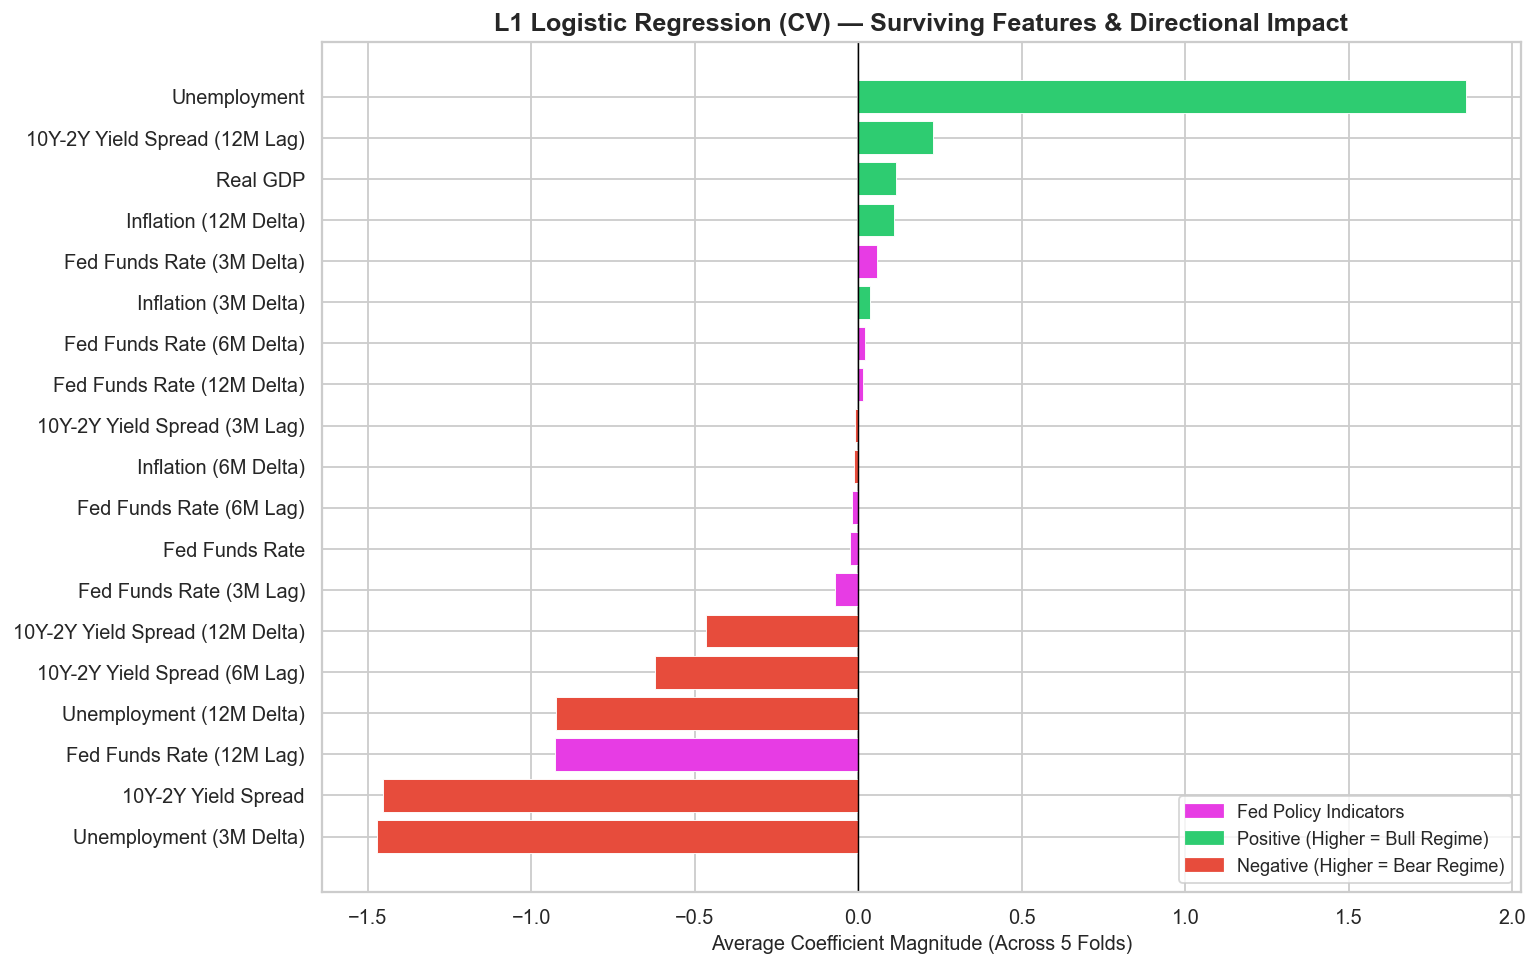

In [18]:
from sklearn.model_selection import TimeSeriesSplit

# Resample to Monthly frequency first
monthly_data = processed_df.resample('ME').last()

MACRO_FULL = ["Fed_Funds_Rate", "10Y2Y_Spread"] 
MACRO_DELTA_ONLY = ["Inflation", "Unemployment"] 
MACRO_RAW = ["Real_GDP"]

# Produce lagged features
ENGINEERED_MACRO = []
for col in MACRO_FULL:
    monthly_data[f'{col}_Lag3M'] = monthly_data[col].shift(3)
    monthly_data[f'{col}_Lag6M'] = monthly_data[col].shift(6)
    monthly_data[f'{col}_Lag12M'] = monthly_data[col].shift(12)
    monthly_data[f'{col}_Delta3M'] = monthly_data[col] - monthly_data[f'{col}_Lag3M']
    monthly_data[f'{col}_Delta6M'] = monthly_data[col] - monthly_data[f'{col}_Lag6M']
    monthly_data[f'{col}_Delta12M'] = monthly_data[col] - monthly_data[f'{col}_Lag12M']
    ENGINEERED_MACRO.extend([f'{col}_Lag3M', f'{col}_Lag6M', f'{col}_Lag12M', f'{col}_Delta3M', f'{col}_Delta6M', f'{col}_Delta12M'])
for col in MACRO_DELTA_ONLY:
    lag3 = monthly_data[col].shift(3)
    lag6 = monthly_data[col].shift(6)
    lag12 = monthly_data[col].shift(12)
    monthly_data[f'{col}_Delta3M'] = monthly_data[col] - lag3
    monthly_data[f'{col}_Delta6M'] = monthly_data[col] - lag6
    monthly_data[f'{col}_Delta12M'] = monthly_data[col] - lag12
    ENGINEERED_MACRO.extend([col, f'{col}_Delta3M', f'{col}_Delta6M', f'{col}_Delta12M'])

# Add the Raw Macro directly to the feature list
ENGINEERED_MACRO.extend(MACRO_RAW)
monthly_data = monthly_data.dropna().copy()

FEATURE_COLS = list(dict.fromkeys(MACRO_FULL + MACRO_DELTA_ONLY + ENGINEERED_MACRO))

X = monthly_data[FEATURE_COLS]
y = monthly_data["Regime"]

# Walkforward Validation

tscv = TimeSeriesSplit(n_splits=5)

global_y_true = []
global_preds = []
fold_lr_coefs = []

print("=" * 60)
print("TIME SERIES WALK-FORWARD VALIDATION (L1 PRUNING)")
print("=" * 60)

fold = 1
for train_index, test_index in tscv.split(X):
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]
    
    # Scale inside the fold
    scaler = StandardScaler()
    X_train_cv_s = pd.DataFrame(scaler.fit_transform(X_train_cv), columns=FEATURE_COLS, index=X_train_cv.index)
    X_test_cv_s = pd.DataFrame(scaler.transform(X_test_cv), columns=FEATURE_COLS, index=X_test_cv.index)
    
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_cv)
    
    # FIX: Use penalty="l1" so it actually prunes
    model = LogisticRegression(l1_ratio=1, solver="liblinear", max_iter=2000, random_state=42)
    model.fit(X_train_cv_s, y_train_cv, sample_weight=sample_weights)
    
    # Save coefficients and predictions
    fold_lr_coefs.append(model.coef_[0])
    
    # Using probability threshold 0.5 for LR
    preds = (model.predict_proba(X_test_cv_s)[:, 1] >= 0.50).astype(int)
    global_preds.extend(preds)
    global_y_true.extend(y_test_cv.values)
    fold += 1

print("\nLogistic Regression — Final Global Metrics:")
print("-" * 40)
print(classification_report(global_y_true, global_preds, target_names=["Bear", "Bull"], zero_division=0))

# Average the coefficients across all 5 folds
avg_lr_coefs = np.mean(fold_lr_coefs, axis=0)
coefs = pd.Series(avg_lr_coefs, index=FEATURE_COLS)

# Filter out features that averaged to exactly zero
coefs = coefs[coefs != 0].sort_values()

def clean_feature_name(name):
    name = name.replace("_", " ")
    name = name.replace("Lag3M", "(3M Lag)")
    name = name.replace("Lag6M", "(6M Lag)")
    name = name.replace("Lag12M", "(12M Lag)")
    name = name.replace("Delta3M", "(3M Delta)")
    name = name.replace("Delta6M", "(6M Delta)")
    name = name.replace("Delta12M", "(12M Delta)")
    name = name.replace("10Y2Y Spread", "10Y-2Y Yield Spread")
    name = name.replace("SPX", "S&P 500")
    return name

clean_labels = [clean_feature_name(f) for f in coefs.index]

fig_height = max(6, len(coefs) * 0.4) 
fig, ax = plt.subplots(figsize=(12, fig_height))

colors = [
    PALETTE["fed"] if "Fed Funds Rate" in f else (PALETTE["pos"] if v > 0 else PALETTE["neg"]) 
    for f, v in zip(clean_labels, coefs.values)
]
ax.barh(clean_labels, coefs.values, color=colors, edgecolor="white", linewidth=0.5)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Average Coefficient Magnitude (Across 5 Folds)", fontsize=11)
ax.set_title("L1 Logistic Regression (CV) — Surviving Features & Directional Impact", fontweight="bold", fontsize=14)
coef_legend = [
    mpatches.Patch(color=PALETTE["fed"], label="Fed Policy Indicators"),
    mpatches.Patch(color=PALETTE["pos"], label="Positive (Higher = Bull Regime)"),
    mpatches.Patch(color=PALETTE["neg"], label="Negative (Higher = Bear Regime)"),
]
ax.legend(handles=coef_legend, loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

# Save the surviving features for the Tree models
final_lr_series = coefs

Plot the walkforward validation setup

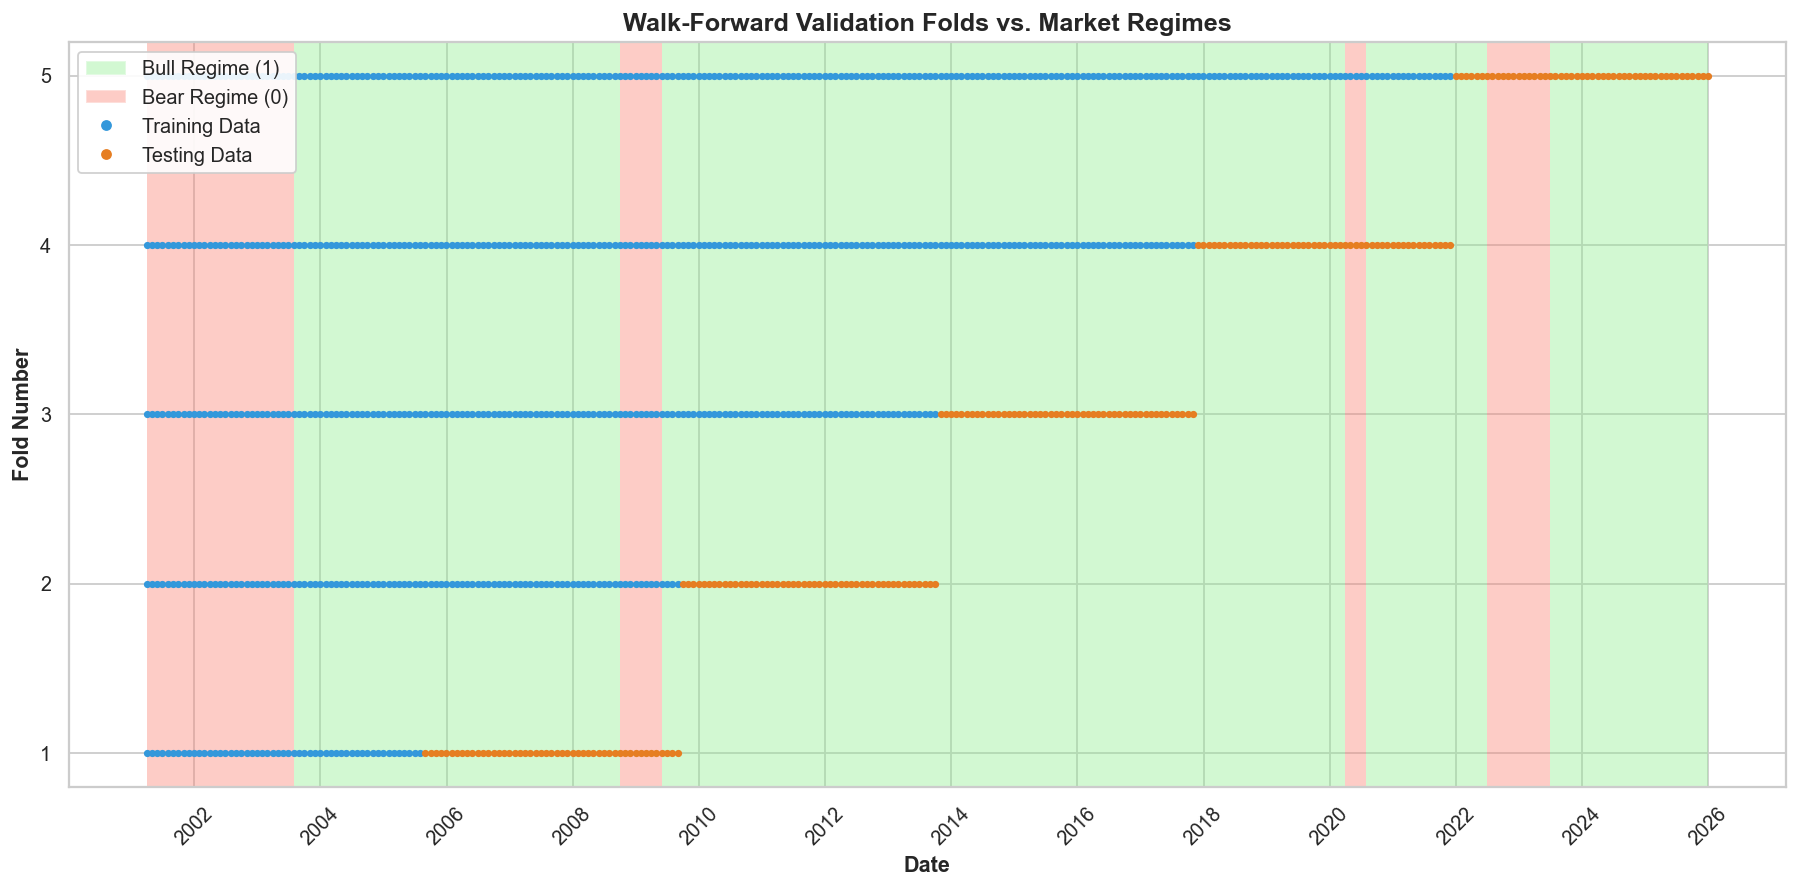

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(14, 7))
dates = y.index
regimes = y.values

# We iterate through the timeline to draw red/green blocks
for i in range(len(dates) - 1):
    color = 'lightgreen' if regimes[i] == 1 else 'salmon'
    ax.axvspan(dates[i], dates[i+1], color=color, alpha=0.4, lw=0)

# Plot the Train and Test folds
tscv = TimeSeriesSplit(n_splits=5)

for i, (train_index, test_index) in enumerate(tscv.split(X)):
    fold_num = i + 1
    train_dates = dates[train_index]
    test_dates = dates[test_index]
    ax.plot(train_dates, [fold_num] * len(train_dates), color='#3498db', marker='.', ls='', markersize=6)
    ax.plot(test_dates, [fold_num] * len(test_dates), color='#e67e22', marker='.', ls='', markersize=6)

ax.set_yticks(range(1, 6))
ax.set_ylabel("Fold Number", fontweight='bold')
ax.set_xlabel("Date", fontweight='bold')
ax.set_title("Walk-Forward Validation Folds vs. Market Regimes", fontweight='bold', fontsize=14)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
legend_elements = [
    Patch(facecolor='lightgreen', alpha=0.4, label='Bull Regime (1)'),
    Patch(facecolor='salmon', alpha=0.4, label='Bear Regime (0)'),
    Line2D([0], [0], marker='.', color='w', markerfacecolor='#3498db', markersize=14, label='Training Data'),
    Line2D([0], [0], marker='.', color='w', markerfacecolor='#e67e22', markersize=14, label='Testing Data')
]
ax.legend(handles=legend_elements, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

### 2) Train Tree-Based Models on Pruned Features

In [20]:
# Pruning
selected_features = coefs[coefs != 0].index.tolist()

print("=" * 60)
print("L1 FEATURE SELECTION SUMMARY")
print("=" * 60)
print(f" Original feature count : {len(FEATURE_COLS)}")
print(f" Pruned feature count   : {len(selected_features)}")
print(f" Eliminated             : {len(FEATURE_COLS) - len(selected_features)} features")
print("-" * 60)
print(" Features Kept:")
for feat in selected_features:
    print(f"  {feat}")
print("=" * 60)

# Walkforward for tree models
models_pruned = {
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=3, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=75, max_depth=2, learning_rate=0.05, random_state=42),
}

# Trackers for global metrics and average importances
global_y_true_pruned = []
global_preds_pruned = {name: [] for name in models_pruned.keys()}
fold_rf_imp = []
fold_gb_imp = []

print("\nRETRAINING TREE MODELS ON PRUNED DATASET (WALK-FORWARD)...")

fold = 1
for train_index, test_index in tscv.split(X):
    # Slice the raw data using ONLY the selected features
    X_train_cv = X.iloc[train_index][selected_features]
    X_test_cv = X.iloc[test_index][selected_features]
    y_train_cv = y.iloc[train_index]
    y_test_cv = y.iloc[test_index]
    
    # Scale inside the loop
    scaler = StandardScaler()
    X_train_cv_s = pd.DataFrame(scaler.fit_transform(X_train_cv), columns=selected_features, index=X_train_cv.index)
    X_test_cv_s = pd.DataFrame(scaler.transform(X_test_cv), columns=selected_features, index=X_test_cv.index)
    
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_cv)
    global_y_true_pruned.extend(y_test_cv.values)

    for name, model in models_pruned.items():
        model.fit(X_train_cv_s, y_train_cv, sample_weight=sample_weights)
        
        # Save Importances
        if name == "Random Forest":
            fold_rf_imp.append(model.feature_importances_)
        elif name == "Gradient Boosting":
            fold_gb_imp.append(model.feature_importances_)
            
        # Predictions
        threshold = 0.5
        preds = (model.predict_proba(X_test_cv_s)[:, 1] >= threshold).astype(int)
        global_preds_pruned[name].extend(preds)
            
    fold += 1

# Aggregated metrics
print("\n" + "=" * 60)
print("FINAL GLOBAL OUT-OF-SAMPLE PERFORMANCE (PRUNED TREES)")
print("=" * 60)
for name in models_pruned.keys():
    print(f"\n{name} — Global Metrics (Threshold 0.50):")
    print("-" * 40)
    print(classification_report(global_y_true_pruned, global_preds_pruned[name], target_names=["Bear", "Bull"], zero_division=0))


L1 FEATURE SELECTION SUMMARY
 Original feature count : 23
 Pruned feature count   : 19
 Eliminated             : 4 features
------------------------------------------------------------
 Features Kept:
  Unemployment_Delta3M
  10Y2Y_Spread
  Fed_Funds_Rate_Lag12M
  Unemployment_Delta12M
  10Y2Y_Spread_Lag6M
  10Y2Y_Spread_Delta12M
  Fed_Funds_Rate_Lag3M
  Fed_Funds_Rate
  Fed_Funds_Rate_Lag6M
  Inflation_Delta6M
  10Y2Y_Spread_Lag3M
  Fed_Funds_Rate_Delta12M
  Fed_Funds_Rate_Delta6M
  Inflation_Delta3M
  Fed_Funds_Rate_Delta3M
  Inflation_Delta12M
  Real_GDP
  10Y2Y_Spread_Lag12M
  Unemployment

RETRAINING TREE MODELS ON PRUNED DATASET (WALK-FORWARD)...

FINAL GLOBAL OUT-OF-SAMPLE PERFORMANCE (PRUNED TREES)

Random Forest — Global Metrics (Threshold 0.50):
----------------------------------------
              precision    recall  f1-score   support

        Bear       0.20      0.50      0.28        24
        Bull       0.93      0.78      0.85       221

    accuracy                 

### 3) Feature Importance (Pruned Features)

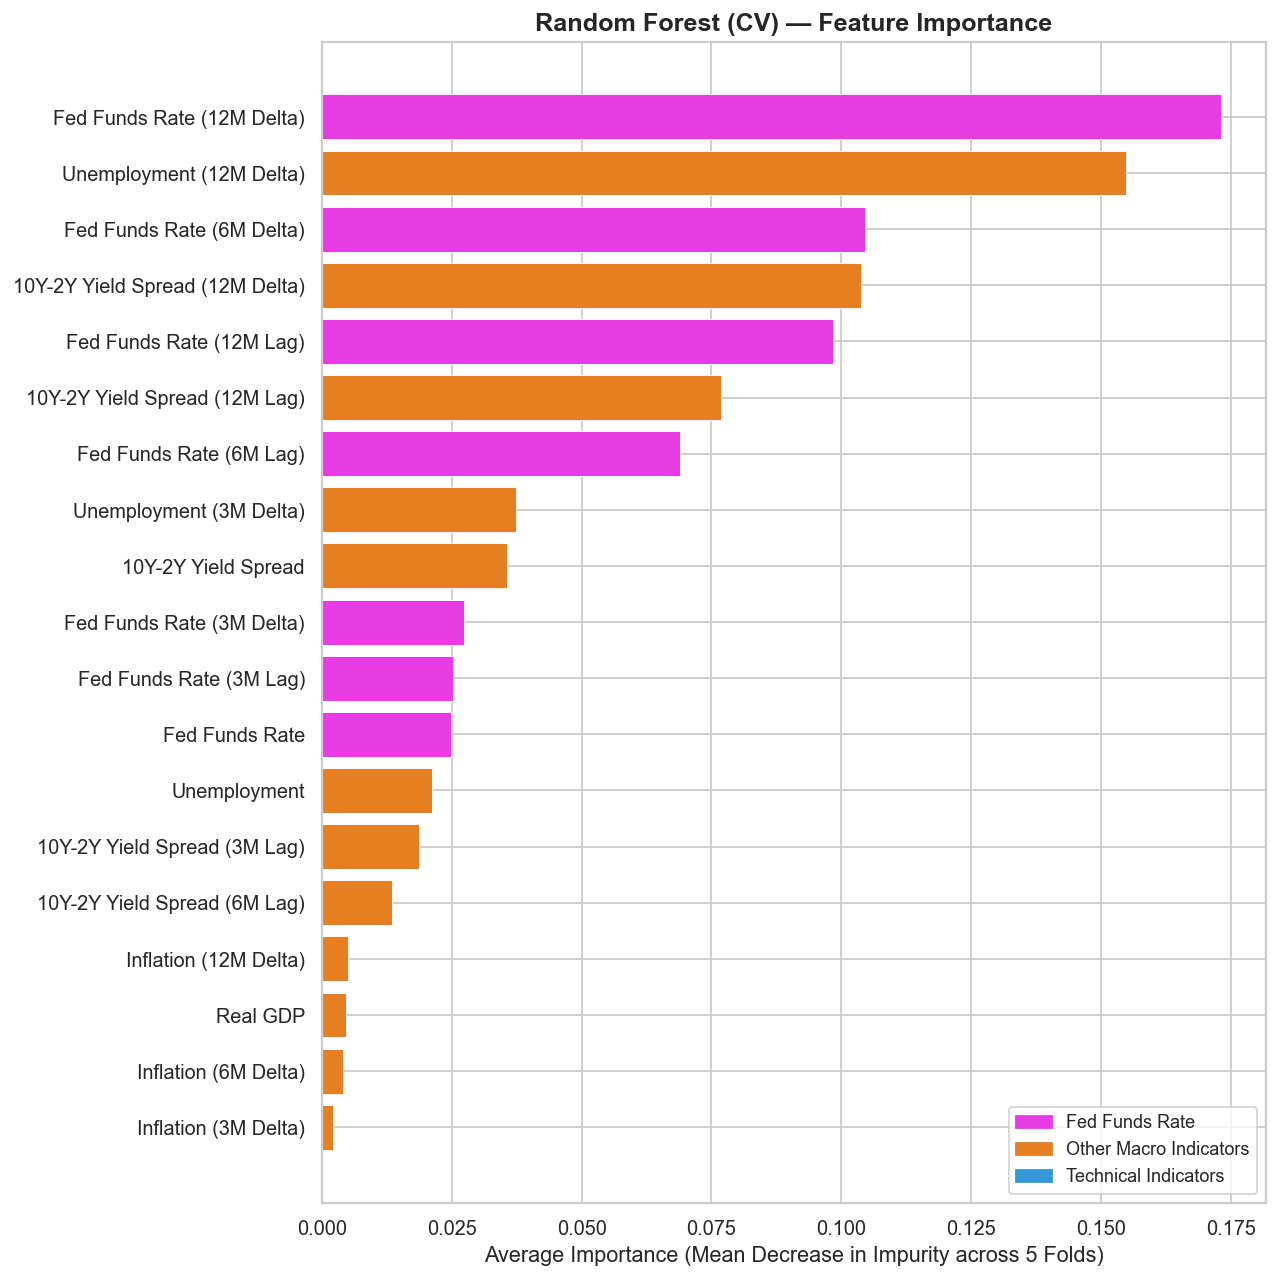

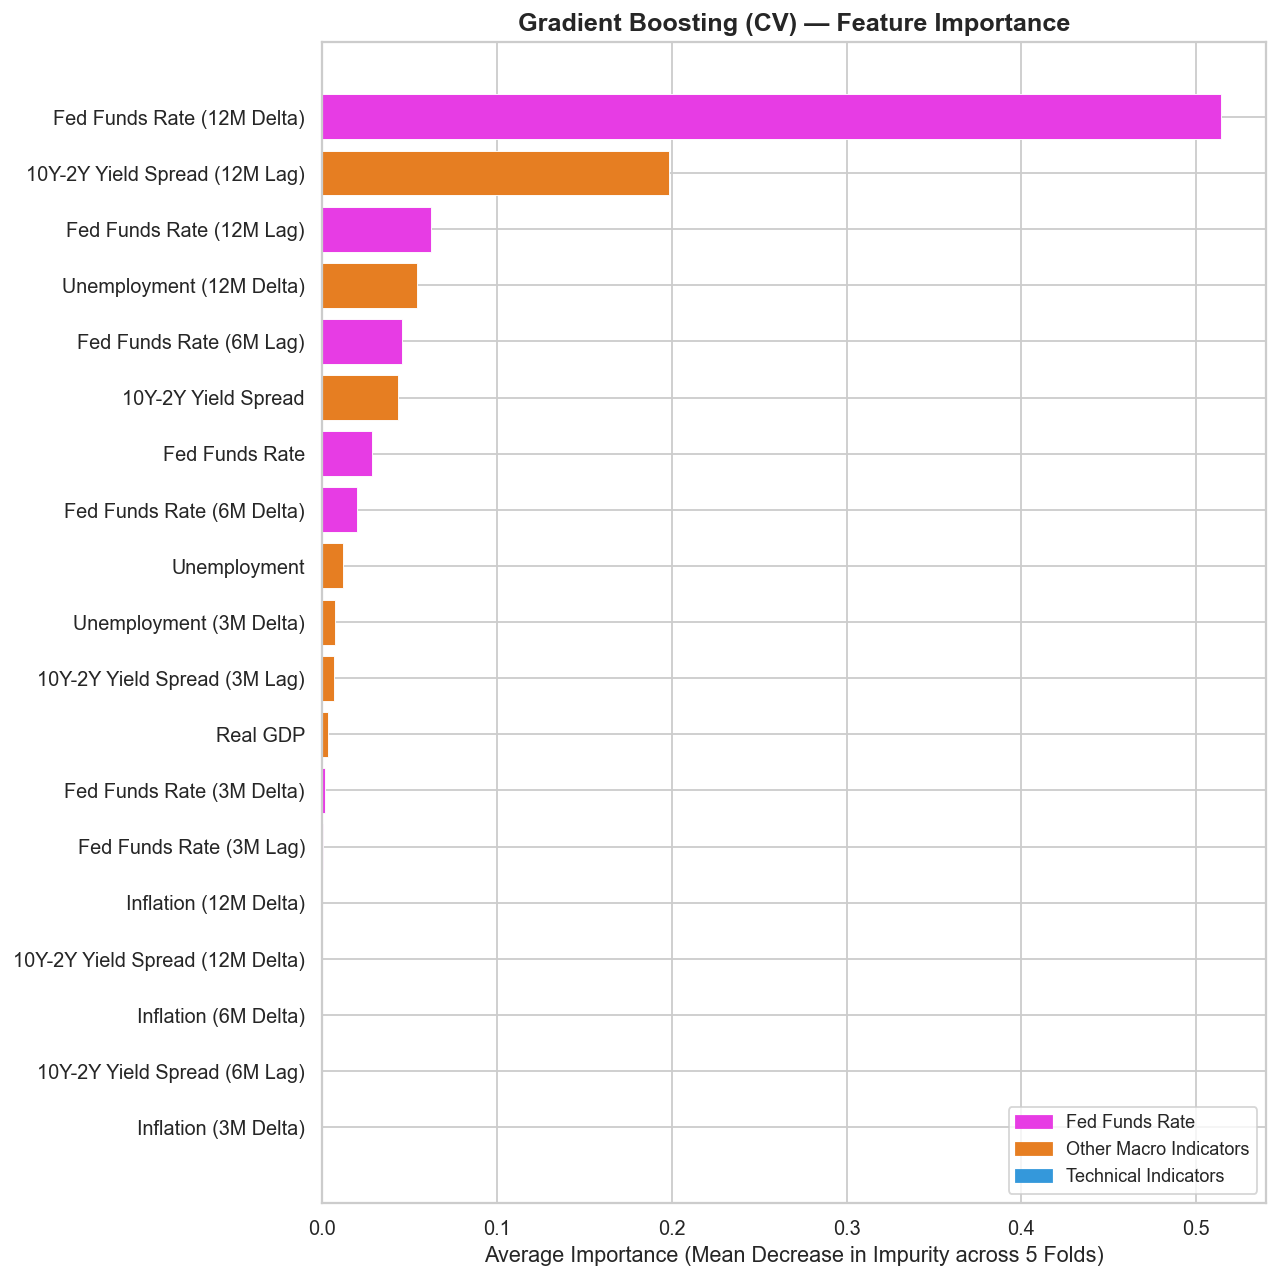

  CROSS-MODEL CONSENSUS: Best Fed Policy Indicator Ranking
  Logistic Regression :  #4 / 23
  Random Forest       :  #1 / 19
  Gradient Boosting   :  #1 / 19

  Average Rank: 2.0


In [21]:
# Random Forest feature importance
avg_rf_imp = np.mean(fold_rf_imp, axis=0)
imp_rf = pd.Series(avg_rf_imp, index=selected_features).sort_values()
clean_labels_rf = [clean_feature_name(f) for f in imp_rf.index]

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(clean_labels_rf, imp_rf.values, color=[feature_color(f) for f in imp_rf.index], edgecolor="white", linewidth=0.5)
ax.set_xlabel("Average Importance (Mean Decrease in Impurity across 5 Folds)")
ax.set_title("Random Forest (CV) — Feature Importance", fontweight="bold")
ax.legend(handles=legend_handles, loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

# Gradient Boosting
avg_gb_imp = np.mean(fold_gb_imp, axis=0)
imp_gb = pd.Series(avg_gb_imp, index=selected_features).sort_values()
clean_labels_gb = [clean_feature_name(f) for f in imp_gb.index]

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(clean_labels_gb, imp_gb.values, color=[feature_color(f) for f in imp_gb.index], edgecolor="white", linewidth=0.5)
ax.set_xlabel("Average Importance (Mean Decrease in Impurity across 5 Folds)")
ax.set_title("Gradient Boosting (CV) — Feature Importance", fontweight="bold")
ax.legend(handles=legend_handles, loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

# Cross-model consensus
def get_best_fed_rank(imp_series, base_name="Fed_Funds_Rate"):
    sorted_features = imp_series.sort_values(ascending=False).index.tolist()
    for i, feat in enumerate(sorted_features):
        if base_name in feat:
            return i + 1 
    return len(imp_series) 

rf_rank  = get_best_fed_rank(imp_rf, "Fed_Funds_Rate")
gb_rank  = get_best_fed_rank(imp_gb, "Fed_Funds_Rate")

abs_coefs = coefs.abs().sort_values(ascending=False)
lr_rank  = get_best_fed_rank(abs_coefs, "Fed_Funds_Rate")

print("=" * 60)
print("  CROSS-MODEL CONSENSUS: Best Fed Policy Indicator Ranking")
print("=" * 60)
print(f"  Logistic Regression :  #{lr_rank} / {len(FEATURE_COLS)}")
print(f"  Random Forest       :  #{rf_rank} / {len(selected_features)}") 
print(f"  Gradient Boosting   :  #{gb_rank} / {len(selected_features)}")
avg_rank = (rf_rank + gb_rank + lr_rank) / 3
print(f"\n  Average Rank: {avg_rank:.1f}")
print("=" * 60)

### 4) Interpretation

- In previous experiments, S\&P500 ROC and RSI completely dominated the feature importance rankings. Because our target variable is defined by a 20% price drop, the model was essentially using the price to predict the price (data leakage).
- After isolating the macro features, the raw Fed_Funds_Rate was largely ignored by the models. Instead, the 12M Delta (momentum) of the Fed Rate emerged as the absolute top predictor across both Random Forest and Gradient Boosting. This suggests that the absolute height of interest rates doesn't 'crash the market' - the shock of rapid rate hikes over a one-year period does.
- Low precision: while our pure macro models successfully identified 50% of the Bear market months out-of-sample, the precision is quite low (~15-20%). The model throws many false alarms. This highlights a core assumption flaw: macroeconomic data can identify a fragile, late-cycle economy, but it moves too slowly to predict the exact month the market will tip over.
- It is possible that we 'over-pruned', effectively throwing out subtle economic indicators that, while weak on their own, might have been powerful when combined with others
- By completely removing technical and sentiment indicators to prevent leakage, we assumed the market is perfectly rational and driven entirely by the real economy. In reality, market psychology matters. A truly optimal model might require a hybrid approach: using macro momentum to gauge the probability of a regime shift, and strict, non-leaking sentiment data to time the exact trigger

# VI. Experiment 4: The Validation Check (All Features + Walk-Forward)

As a sanity check, we reintroduce the technical indicators into the Walk-Forward testing framework. As expected, the models immediately reverted to relying heavily on RSI and MACD, artificially inflating performance across all folds. This confirmed our thesis: to build a true economic forecasting tool, technical indicators must be excluded to prevent the model from "cheating."

### 1) Setup and Model Training

The setup and models are kept the same as in the previous experiment, with the addition of the original technical indicators.

TIME SERIES WALK-FORWARD VALIDATION (L1 PRUNING)

Logistic Regression — Final Global Metrics:
----------------------------------------
              precision    recall  f1-score   support

        Bear       0.40      0.33      0.36        24
        Bull       0.93      0.95      0.94       221

    accuracy                           0.89       245
   macro avg       0.66      0.64      0.65       245
weighted avg       0.88      0.89      0.88       245



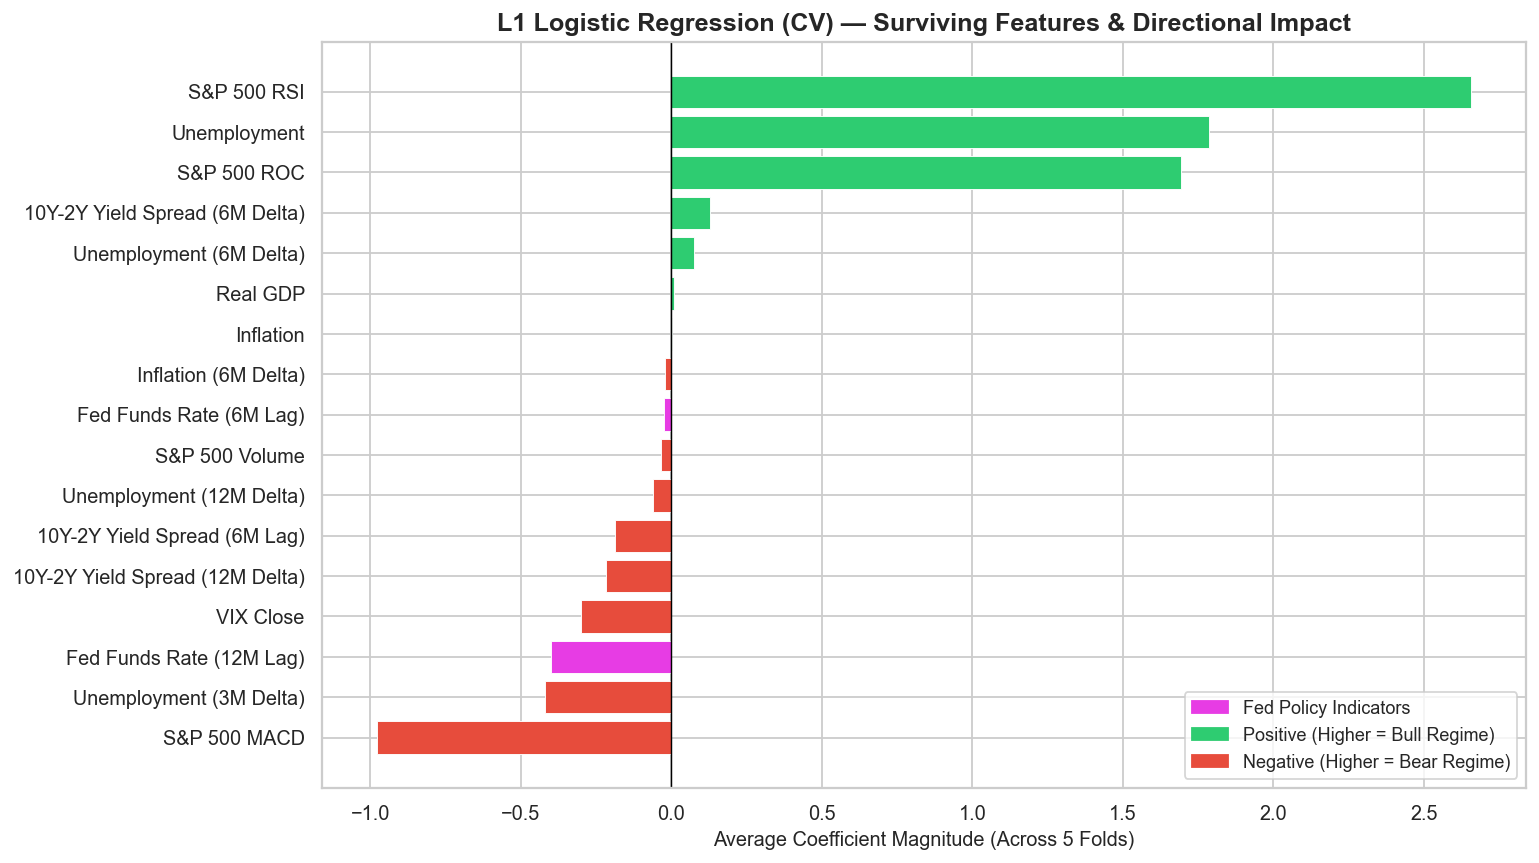

In [22]:
from sklearn.model_selection import TimeSeriesSplit

# Resample to Monthly frequency first
monthly_data = processed_df.resample('ME').last()

MACRO_FULL = ["Fed_Funds_Rate", "10Y2Y_Spread"] 
MACRO_DELTA_ONLY = ["Inflation", "Unemployment"] 
MACRO_RAW = ["Real_GDP"]

# Produce lagged features
ENGINEERED_MACRO = []
for col in MACRO_FULL:
    monthly_data[f'{col}_Lag3M'] = monthly_data[col].shift(3)
    monthly_data[f'{col}_Lag6M'] = monthly_data[col].shift(6)
    monthly_data[f'{col}_Lag12M'] = monthly_data[col].shift(12)
    monthly_data[f'{col}_Delta3M'] = monthly_data[col] - monthly_data[f'{col}_Lag3M']
    monthly_data[f'{col}_Delta6M'] = monthly_data[col] - monthly_data[f'{col}_Lag6M']
    monthly_data[f'{col}_Delta12M'] = monthly_data[col] - monthly_data[f'{col}_Lag12M']
    ENGINEERED_MACRO.extend([f'{col}_Lag3M', f'{col}_Lag6M', f'{col}_Lag12M', f'{col}_Delta3M', f'{col}_Delta6M', f'{col}_Delta12M'])
for col in MACRO_DELTA_ONLY:
    lag3 = monthly_data[col].shift(3)
    lag6 = monthly_data[col].shift(6)
    lag12 = monthly_data[col].shift(12)
    monthly_data[f'{col}_Delta3M'] = monthly_data[col] - lag3
    monthly_data[f'{col}_Delta6M'] = monthly_data[col] - lag6
    monthly_data[f'{col}_Delta12M'] = monthly_data[col] - lag12
    ENGINEERED_MACRO.extend([col, f'{col}_Delta3M', f'{col}_Delta6M', f'{col}_Delta12M'])

# Add the Raw Macro directly to the feature list
ENGINEERED_MACRO.extend(MACRO_RAW)
monthly_data = monthly_data.dropna().copy()

TECHNICALS = [
    "SPX_Volume", "SPX_ROC", "SPX_RSI", "SPX_MACD", "SPX_MACDH", "VIX_Close"
]

FEATURE_COLS = list(dict.fromkeys(TECHNICALS + MACRO_FULL + MACRO_DELTA_ONLY + ENGINEERED_MACRO))

X = monthly_data[FEATURE_COLS]
y = monthly_data["Regime"]

# Walkforward Validation

tscv = TimeSeriesSplit(n_splits=5)

global_y_true = []
global_preds = []
fold_lr_coefs = []

print("=" * 60)
print("TIME SERIES WALK-FORWARD VALIDATION (L1 PRUNING)")
print("=" * 60)

fold = 1
for train_index, test_index in tscv.split(X):
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]
    
    # Scale inside the fold
    scaler = StandardScaler()
    X_train_cv_s = pd.DataFrame(scaler.fit_transform(X_train_cv), columns=FEATURE_COLS, index=X_train_cv.index)
    X_test_cv_s = pd.DataFrame(scaler.transform(X_test_cv), columns=FEATURE_COLS, index=X_test_cv.index)
    
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_cv)
    
    # FIX: Use penalty="l1" so it actually prunes
    model = LogisticRegression(l1_ratio=1, solver="liblinear", max_iter=2000, random_state=42)
    model.fit(X_train_cv_s, y_train_cv, sample_weight=sample_weights)
    
    # Save coefficients and predictions
    fold_lr_coefs.append(model.coef_[0])
    
    # Using probability threshold 0.5 for LR
    preds = (model.predict_proba(X_test_cv_s)[:, 1] >= 0.50).astype(int)
    global_preds.extend(preds)
    global_y_true.extend(y_test_cv.values)
    fold += 1

print("\nLogistic Regression — Final Global Metrics:")
print("-" * 40)
print(classification_report(global_y_true, global_preds, target_names=["Bear", "Bull"], zero_division=0))

# Average the coefficients across all 5 folds
avg_lr_coefs = np.mean(fold_lr_coefs, axis=0)
coefs = pd.Series(avg_lr_coefs, index=FEATURE_COLS)

# Filter out features that averaged to exactly zero
coefs = coefs[coefs != 0].sort_values()

def clean_feature_name(name):
    name = name.replace("_", " ")
    name = name.replace("Lag3M", "(3M Lag)")
    name = name.replace("Lag6M", "(6M Lag)")
    name = name.replace("Lag12M", "(12M Lag)")
    name = name.replace("Delta3M", "(3M Delta)")
    name = name.replace("Delta6M", "(6M Delta)")
    name = name.replace("Delta12M", "(12M Delta)")
    name = name.replace("10Y2Y Spread", "10Y-2Y Yield Spread")
    name = name.replace("SPX", "S&P 500")
    return name

clean_labels = [clean_feature_name(f) for f in coefs.index]

fig_height = max(6, len(coefs) * 0.4) 
fig, ax = plt.subplots(figsize=(12, fig_height))

colors = [
    PALETTE["fed"] if "Fed Funds Rate" in f else (PALETTE["pos"] if v > 0 else PALETTE["neg"]) 
    for f, v in zip(clean_labels, coefs.values)
]
ax.barh(clean_labels, coefs.values, color=colors, edgecolor="white", linewidth=0.5)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Average Coefficient Magnitude (Across 5 Folds)", fontsize=11)
ax.set_title("L1 Logistic Regression (CV) — Surviving Features & Directional Impact", fontweight="bold", fontsize=14)
coef_legend = [
    mpatches.Patch(color=PALETTE["fed"], label="Fed Policy Indicators"),
    mpatches.Patch(color=PALETTE["pos"], label="Positive (Higher = Bull Regime)"),
    mpatches.Patch(color=PALETTE["neg"], label="Negative (Higher = Bear Regime)"),
]
ax.legend(handles=coef_legend, loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

# Save the surviving features for the Tree models
final_lr_series = coefs

### 2) Train Tree-Based Models on Pruned Features

In [23]:
# Pruning
selected_features = coefs[coefs != 0].index.tolist()

print("=" * 60)
print("L1 FEATURE SELECTION SUMMARY")
print("=" * 60)
print(f" Original feature count : {len(FEATURE_COLS)}")
print(f" Pruned feature count   : {len(selected_features)}")
print(f" Eliminated             : {len(FEATURE_COLS) - len(selected_features)} features")
print("-" * 60)
print(" Features Kept:")
for feat in selected_features:
    print(f"  {feat}")
print("=" * 60)

# Walkforward for tree models
models_pruned = {
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=3, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=75, max_depth=2, learning_rate=0.05, random_state=42),
}

# Trackers for global metrics and average importances
global_y_true_pruned = []
global_preds_pruned = {name: [] for name in models_pruned.keys()}
fold_rf_imp = []
fold_gb_imp = []

print("\nRETRAINING TREE MODELS ON PRUNED DATASET (WALK-FORWARD)...")

fold = 1
for train_index, test_index in tscv.split(X):
    # Slice the raw data using ONLY the selected features
    X_train_cv = X.iloc[train_index][selected_features]
    X_test_cv = X.iloc[test_index][selected_features]
    y_train_cv = y.iloc[train_index]
    y_test_cv = y.iloc[test_index]
    
    # Scale inside the loop
    scaler = StandardScaler()
    X_train_cv_s = pd.DataFrame(scaler.fit_transform(X_train_cv), columns=selected_features, index=X_train_cv.index)
    X_test_cv_s = pd.DataFrame(scaler.transform(X_test_cv), columns=selected_features, index=X_test_cv.index)
    
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_cv)
    global_y_true_pruned.extend(y_test_cv.values)

    for name, model in models_pruned.items():
        model.fit(X_train_cv_s, y_train_cv, sample_weight=sample_weights)
        
        # Save Importances
        if name == "Random Forest":
            fold_rf_imp.append(model.feature_importances_)
        elif name == "Gradient Boosting":
            fold_gb_imp.append(model.feature_importances_)
            
        # Predictions
        threshold = 0.5
        preds = (model.predict_proba(X_test_cv_s)[:, 1] >= threshold).astype(int)
        global_preds_pruned[name].extend(preds)
            
    fold += 1

# Aggregated metrics
print("\n" + "=" * 60)
print("FINAL GLOBAL OUT-OF-SAMPLE PERFORMANCE (PRUNED TREES)")
print("=" * 60)
for name in models_pruned.keys():
    print(f"\n{name} — Global Metrics (Threshold 0.50):")
    print("-" * 40)
    print(classification_report(global_y_true_pruned, global_preds_pruned[name], target_names=["Bear", "Bull"], zero_division=0))


L1 FEATURE SELECTION SUMMARY
 Original feature count : 29
 Pruned feature count   : 17
 Eliminated             : 12 features
------------------------------------------------------------
 Features Kept:
  SPX_MACD
  Unemployment_Delta3M
  Fed_Funds_Rate_Lag12M
  VIX_Close
  10Y2Y_Spread_Delta12M
  10Y2Y_Spread_Lag6M
  Unemployment_Delta12M
  SPX_Volume
  Fed_Funds_Rate_Lag6M
  Inflation_Delta6M
  Inflation
  Real_GDP
  Unemployment_Delta6M
  10Y2Y_Spread_Delta6M
  SPX_ROC
  Unemployment
  SPX_RSI

RETRAINING TREE MODELS ON PRUNED DATASET (WALK-FORWARD)...

FINAL GLOBAL OUT-OF-SAMPLE PERFORMANCE (PRUNED TREES)

Random Forest — Global Metrics (Threshold 0.50):
----------------------------------------
              precision    recall  f1-score   support

        Bear       0.43      0.38      0.40        24
        Bull       0.93      0.95      0.94       221

    accuracy                           0.89       245
   macro avg       0.68      0.66      0.67       245
weighted avg       0.

### 3) Feature Importance (Pruned Features)

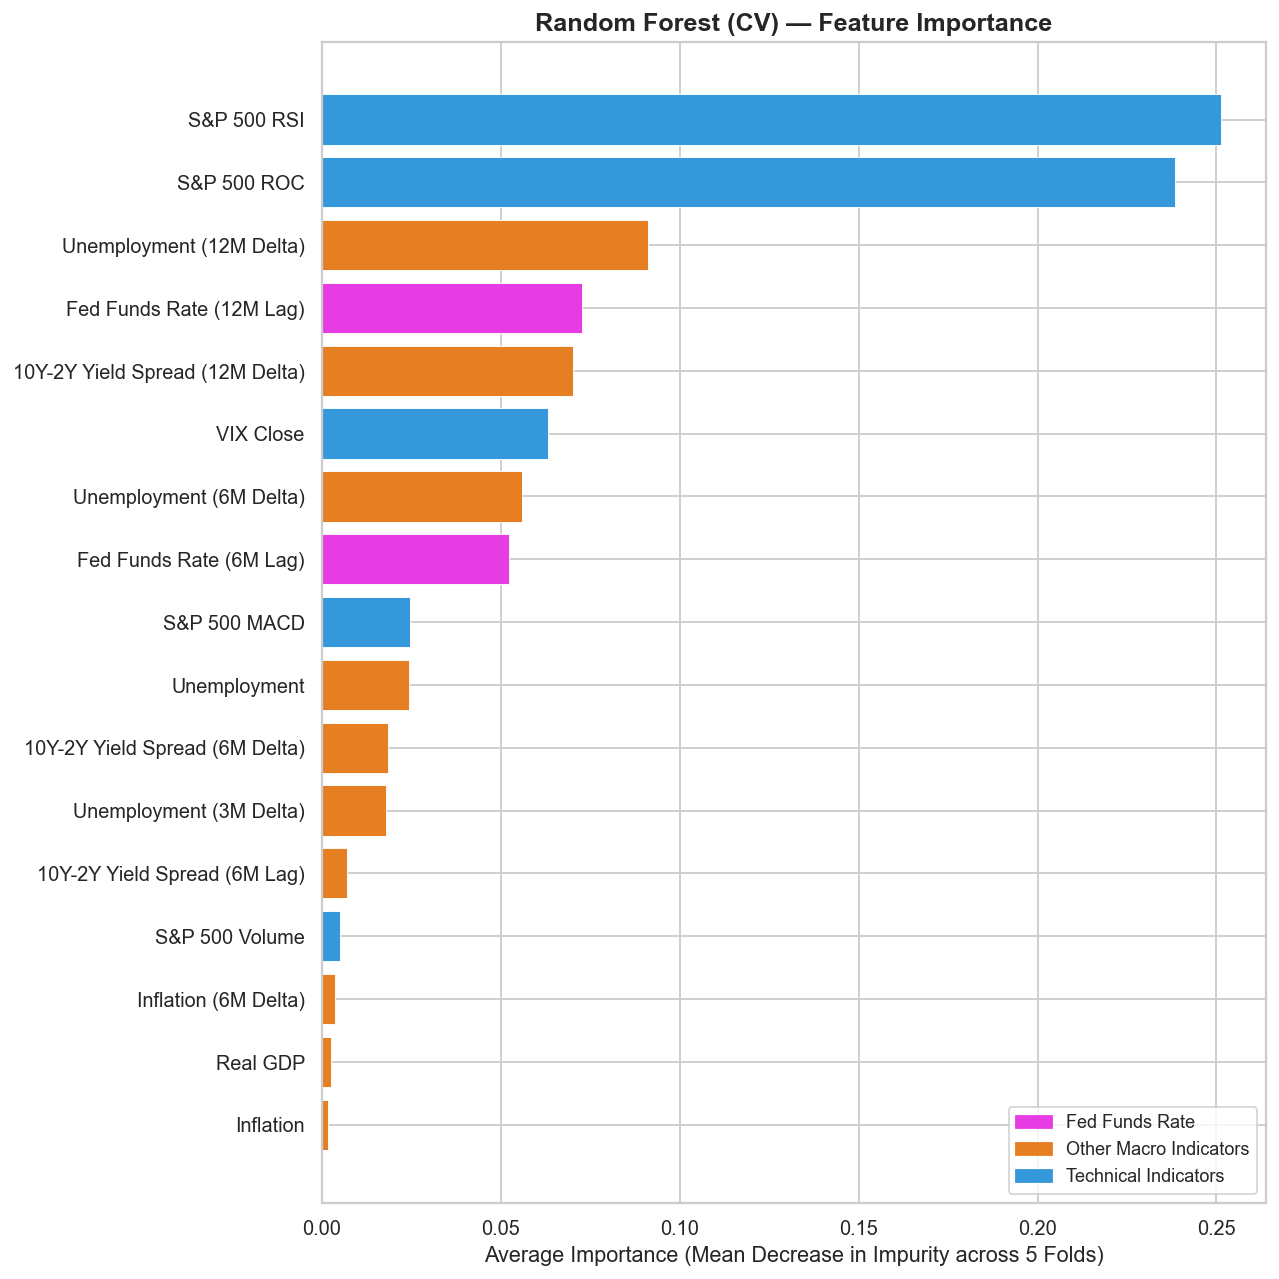

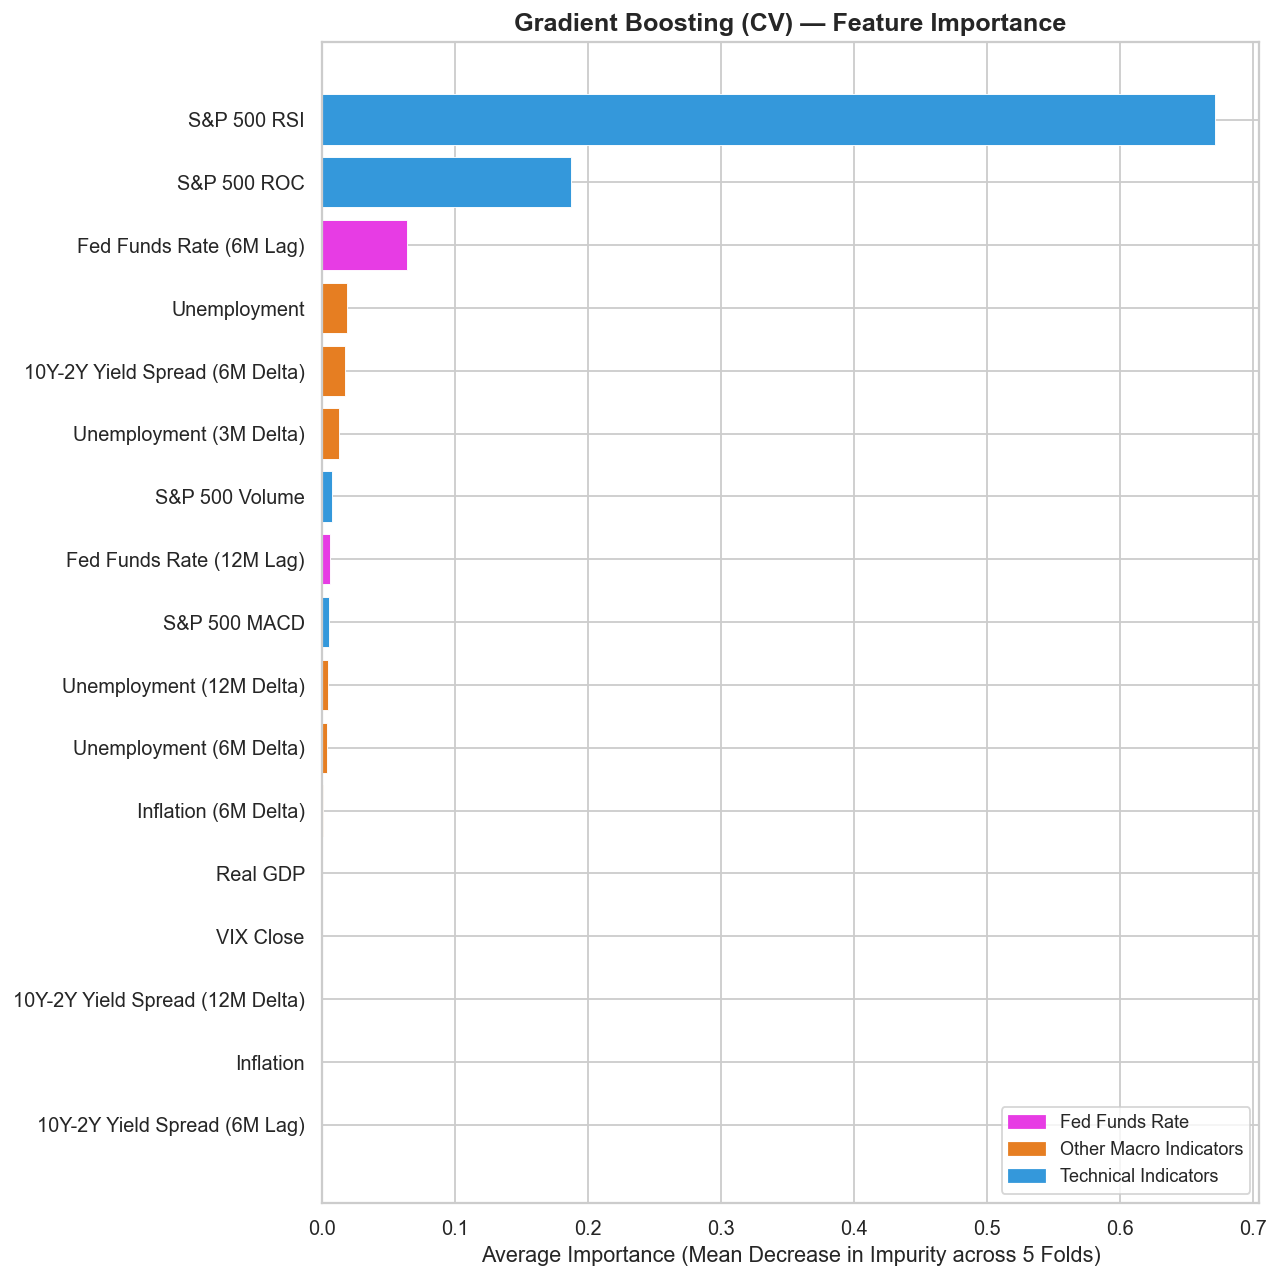

  CROSS-MODEL CONSENSUS: Best Fed Policy Indicator Ranking
  Logistic Regression :  #6 / 29
  Random Forest       :  #4 / 17
  Gradient Boosting   :  #3 / 17

  Average Rank: 4.3


In [24]:
# Random Forest feature importance
avg_rf_imp = np.mean(fold_rf_imp, axis=0)
imp_rf = pd.Series(avg_rf_imp, index=selected_features).sort_values()
clean_labels_rf = [clean_feature_name(f) for f in imp_rf.index]

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(clean_labels_rf, imp_rf.values, color=[feature_color(f) for f in imp_rf.index], edgecolor="white", linewidth=0.5)
ax.set_xlabel("Average Importance (Mean Decrease in Impurity across 5 Folds)")
ax.set_title("Random Forest (CV) — Feature Importance", fontweight="bold")
ax.legend(handles=legend_handles, loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

# Gradient Boosting
avg_gb_imp = np.mean(fold_gb_imp, axis=0)
imp_gb = pd.Series(avg_gb_imp, index=selected_features).sort_values()
clean_labels_gb = [clean_feature_name(f) for f in imp_gb.index]

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(clean_labels_gb, imp_gb.values, color=[feature_color(f) for f in imp_gb.index], edgecolor="white", linewidth=0.5)
ax.set_xlabel("Average Importance (Mean Decrease in Impurity across 5 Folds)")
ax.set_title("Gradient Boosting (CV) — Feature Importance", fontweight="bold")
ax.legend(handles=legend_handles, loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

# Cross-model consensus
def get_best_fed_rank(imp_series, base_name="Fed_Funds_Rate"):
    sorted_features = imp_series.sort_values(ascending=False).index.tolist()
    for i, feat in enumerate(sorted_features):
        if base_name in feat:
            return i + 1 
    return len(imp_series) 

rf_rank  = get_best_fed_rank(imp_rf, "Fed_Funds_Rate")
gb_rank  = get_best_fed_rank(imp_gb, "Fed_Funds_Rate")

abs_coefs = coefs.abs().sort_values(ascending=False)
lr_rank  = get_best_fed_rank(abs_coefs, "Fed_Funds_Rate")

print("=" * 60)
print("  CROSS-MODEL CONSENSUS: Best Fed Policy Indicator Ranking")
print("=" * 60)
print(f"  Logistic Regression :  #{lr_rank} / {len(FEATURE_COLS)}")
print(f"  Random Forest       :  #{rf_rank} / {len(selected_features)}") 
print(f"  Gradient Boosting   :  #{gb_rank} / {len(selected_features)}")
avg_rank = (rf_rank + gb_rank + lr_rank) / 3
print(f"\n  Average Rank: {avg_rank:.1f}")
print("=" * 60)

### 4) Interpretation

As expected, the models revert to putting heavy importance on price-derived technical indicators (S\&P 500 RSI, ROC)